In [1]:

!pip install pandas --quiet
!pip install matplotlib --quiet
!pip install xlrd --quiet
import pandas as pd

# EDA

In [2]:

!pip install seaborn --quiet
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
import pandas as pd

data_file_path = "data/survey1.xls"

df = pd.read_excel(
    data_file_path,
    header=[1,2],
    index_col=0
)

ddf = df.copy()

df.columns = [
    f"{str(a).strip()}&{str(b).strip()}"
    for a,b in df.columns
]

df.columns = [
    col.replace(".1", "")
       .replace(".2", "")
       .replace(".3", "")
       .replace(".4", "")
    for col in df.columns
]

df.columns = [
    "1.1. Name of organization",
    "1.2. Type of business"
] + list(df.columns[2:])


df.columns = df.columns.map(
    lambda x:
        x.replace("1.1.", "")
         .replace("1.2.", "")
         .strip()

        if "&" not in x

        else f'{"".join(w[0] for w in x.split("&")[0].split())}_ {x.split("&")[1].strip()}'
)


In [4]:
df.sample(5)

,Name of organization,Type of business,AMF_ Types of machine,AMF_ Maximum number of tools available,AMF_ Maximum number of operation available,AMF_ Tool magazine or tool turret capacity,AMF_ Tool changing time,AMF_ Type of operations to be done on machine,AMF_ Variety of parts to be handled by the machine,AMF_ Skills and versatility of workers,...,ARF_ Common tooling available,ARF_ Space availability,ARF_ Availability of technical know how,ARF_ Flexibility of material handling system,ARF_ Similarities of parts in the system,APF_ Design changes required in the product,APF_ Variety of products,APF_ Offline part programming preparation facility,APF_ Number of existing part families matching the new product design,APF_ Machine flexibility
78.0,Essar Steel,Steel Manufacturing,4.0,4.0,5.0,5.0,3.0,5.0,4.0,4.0,...,5.0,4.0,4.0,5.0,4.0,5.0,4.0,5.0,4.0,4.0
99.0,Genext Technologies,"Engineering parts ,auto parts",4.0,4.0,5.0,5.0,4.0,3.0,5.0,4.0,...,5.0,4.0,5.0,4.0,5.0,4.0,5.0,5.0,4.0,5.0
50.0,plaster polymers,auto components,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,5.0,4.0,4.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0
69.0,Honeywell Automation,Automobile Engineering,3.0,4.0,3.0,4.0,4.0,4.0,4.0,4.0,...,3.0,4.0,3.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0
70.0,Golden Engineering Co.,Auto Parts Manufacturing,4.0,5.0,4.0,3.0,5.0,4.0,4.0,3.0,...,4.0,5.0,4.0,5.0,4.0,4.0,3.0,4.0,4.0,5.0


In [5]:
df.dropna(inplace=True)

df.drop_duplicates(subset='Name of organization',inplace=True)

In [6]:
amf_cols = [col.split("AMF_ ")[1] for col in df.columns if col.startswith("AMF_")]
arf_cols = [col.split("ARF_ ")[1] for col in df.columns if col.startswith("ARF_")]
apf_cols = [col.split("APF_ ")[1] for col in df.columns if col.startswith("APF_")]

In [7]:
df.columns=[x if "_ " not in x else x.split("_ ")[1] for x in df.columns]

In [8]:
df

,Name of organization,Type of business,Types of machine,Maximum number of tools available,Maximum number of operation available,Tool magazine or tool turret capacity,Tool changing time,Type of operations to be done on machine,Variety of parts to be handled by the machine,Skills and versatility of workers,...,Common tooling available,Space availability,Availability of technical know how,Flexibility of material handling system,Similarities of parts in the system,Design changes required in the product,Variety of products,Offline part programming preparation facility,Number of existing part families matching the new product design,Machine flexibility
1.0,Relaible Bitumen,Manufacturer of Bitumen drums,4.0,5.0,4.0,5.0,4.0,5.0,4.0,5.0,...,5.0,4.0,5.0,4.0,5.0,4.0,5.0,4.0,5.0,4.0
2.0,Ashok Leyland Ltd,Automobile,5.0,4.0,5.0,5.0,4.0,3.0,4.0,5.0,...,3.0,4.0,5.0,4.0,5.0,4.0,5.0,4.0,3.0,5.0
3.0,Super Circle India Pvt. Ltd.,Manufacturer of Vehicle Parts,4.0,5.0,4.0,5.0,4.0,5.0,4.0,5.0,...,5.0,4.0,4.0,4.0,5.0,4.0,5.0,5.0,5.0,4.0
4.0,Mita India Pvt. Ltd.,Manufaturer Of Tractor Parts,4.0,5.0,4.0,5.0,4.0,5.0,4.0,5.0,...,5.0,4.0,5.0,4.0,5.0,4.0,5.0,4.0,5.0,4.0
5.0,Bajaj Auto Ltd.,Automobile Ancilliaries,5.0,4.0,5.0,4.0,4.0,5.0,5.0,5.0,...,5.0,4.0,5.0,3.0,4.0,5.0,4.0,4.0,5.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98.0,Intra Continental Engineering Corporatio...,Engineering Machine,5.0,4.0,5.0,4.0,5.0,4.0,3.0,4.0,...,5.0,4.0,5.0,4.0,5.0,4.0,3.0,5.0,3.0,5.0
99.0,Genext Technologies,"Engineering parts ,auto parts",4.0,4.0,5.0,5.0,4.0,3.0,5.0,4.0,...,5.0,4.0,5.0,4.0,5.0,4.0,5.0,5.0,4.0,5.0
100.0,La Gajjar Machineries PVT LT,Motor Pump,5.0,4.0,3.0,4.0,4.0,5.0,4.0,3.0,...,4.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,5.0,4.0
101.0,GKN driveline India Ltd.,Automobile Ancillary,4.0,3.0,3.0,2.0,4.0,3.0,4.0,4.0,...,4.0,4.0,5.0,4.0,2.0,4.0,4.0,4.0,4.0,4.0


In [9]:
df.sample(10)

,Name of organization,Type of business,Types of machine,Maximum number of tools available,Maximum number of operation available,Tool magazine or tool turret capacity,Tool changing time,Type of operations to be done on machine,Variety of parts to be handled by the machine,Skills and versatility of workers,...,Common tooling available,Space availability,Availability of technical know how,Flexibility of material handling system,Similarities of parts in the system,Design changes required in the product,Variety of products,Offline part programming preparation facility,Number of existing part families matching the new product design,Machine flexibility
47.0,Esvee prescision L.T.D,Auto parts,4.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0,...,4.0,5.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,4.0
53.0,strok auto pvt.ltd,Auto parts,4.0,4.0,5.0,4.0,4.0,5.0,4.0,4.0,...,4.0,4.0,4.0,5.0,5.0,4.0,5.0,4.0,4.0,5.0
2.0,Ashok Leyland Ltd,Automobile,5.0,4.0,5.0,5.0,4.0,3.0,4.0,5.0,...,3.0,4.0,5.0,4.0,5.0,4.0,5.0,4.0,3.0,5.0
35.0,sunvisor India Pvt.Ltd,Parts of connecting Road For maruti,4.0,4.0,3.0,4.0,5.0,4.0,4.0,4.0,...,3.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0,5.0,5.0
55.0,ranee polymers pvt ltd,Auto parts,4.0,4.0,4.0,5.0,4.0,3.0,4.0,5.0,...,4.0,4.0,5.0,4.0,4.0,4.0,4.0,3.0,4.0,4.0
4.0,Mita India Pvt. Ltd.,Manufaturer Of Tractor Parts,4.0,5.0,4.0,5.0,4.0,5.0,4.0,5.0,...,5.0,4.0,5.0,4.0,5.0,4.0,5.0,4.0,5.0,4.0
20.0,Greaves Cotton Ltd.,Auotmobile,4.0,5.0,4.0,5.0,4.0,5.0,4.0,5.0,...,3.0,4.0,5.0,4.0,4.0,5.0,5.0,4.0,4.0,5.0
97.0,Sudhir Gensets Ltd,Generator & DG Sets,4.0,5.0,4.0,5.0,4.0,3.0,4.0,5.0,...,3.0,4.0,4.0,5.0,4.0,5.0,4.0,3.0,4.0,5.0
64.0,Richo Ltd,Auto Parts Manufacturing,5.0,5.0,4.0,4.0,5.0,4.0,4.0,5.0,...,5.0,4.0,5.0,5.0,5.0,4.0,4.0,4.0,3.0,4.0
101.0,GKN driveline India Ltd.,Automobile Ancillary,4.0,3.0,3.0,2.0,4.0,3.0,4.0,4.0,...,4.0,4.0,5.0,4.0,2.0,4.0,4.0,4.0,4.0,4.0


In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 100 entries, 1.0 to 103.0
Data columns (total 24 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Name of organization                                              100 non-null    str    
 1   Type of business                                                  100 non-null    str    
 2   Types of machine                                                  100 non-null    float64
 3   Maximum number of tools available                                 100 non-null    float64
 4   Maximum number of operation available                             100 non-null    float64
 5   Tool magazine or tool turret capacity                             100 non-null    float64
 6   Tool changing time                                                100 non-null    float64
 7   Type of operations to be done on machine       

In [11]:
df.describe()

,Types of machine,Maximum number of tools available,Maximum number of operation available,Tool magazine or tool turret capacity,Tool changing time,Type of operations to be done on machine,Variety of parts to be handled by the machine,Skills and versatility of workers,Setup or changeover time,Number of machines available in the system,...,Common tooling available,Space availability,Availability of technical know how,Flexibility of material handling system,Similarities of parts in the system,Design changes required in the product,Variety of products,Offline part programming preparation facility,Number of existing part families matching the new product design,Machine flexibility
count,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,4.260000,4.250000,4.19000,4.330000,4.160000,4.090000,4.200000,4.290000,4.330000,4.260000,...,4.170000,4.190000,4.330000,4.160000,4.190000,4.160000,4.170000,4.100000,4.130000,4.340000
std,0.660884,0.657129,0.72048,0.739301,0.631177,0.697687,0.603023,0.700577,0.620443,0.660884,...,0.766139,0.580752,0.682464,0.646982,0.787465,0.631177,0.636515,0.717741,0.691288,0.669992
min,3.000000,3.000000,3.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,2.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,3.000000
25%,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
50%,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
75%,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


/tmp/ipykernel_5362/1823164876.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


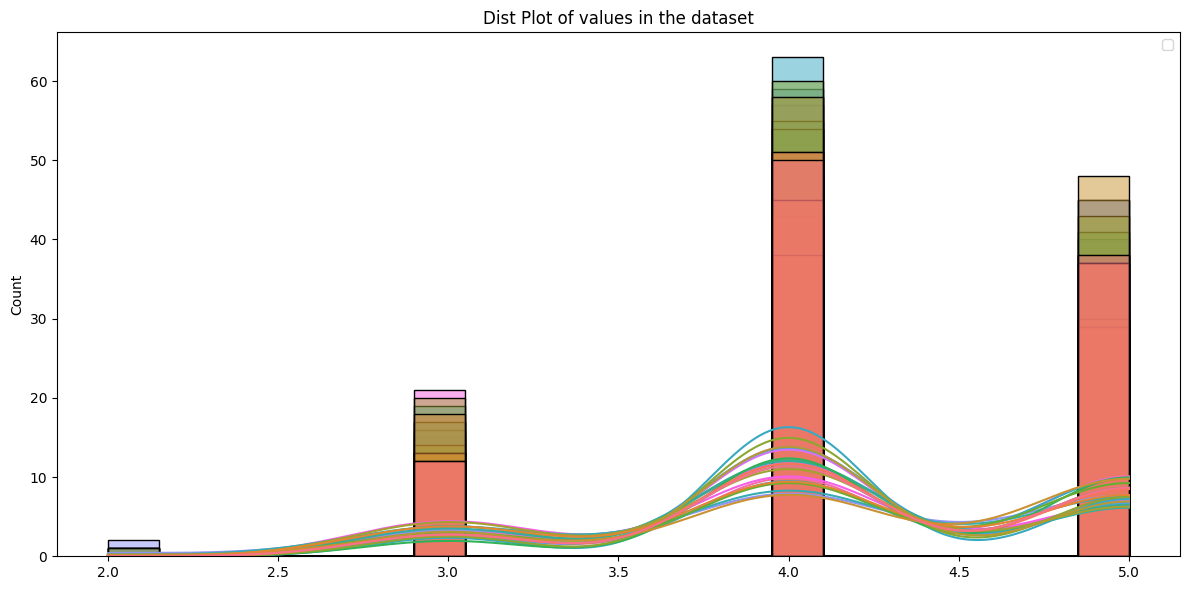

In [12]:
plt.figure(figsize=(12,6))

sns.histplot(df, kde=True)

plt.title("Dist Plot of values in the dataset")
plt.legend()
plt.tight_layout()

plt.show()

<Axes: xlabel='Availability of technical know how', ylabel='Density'>

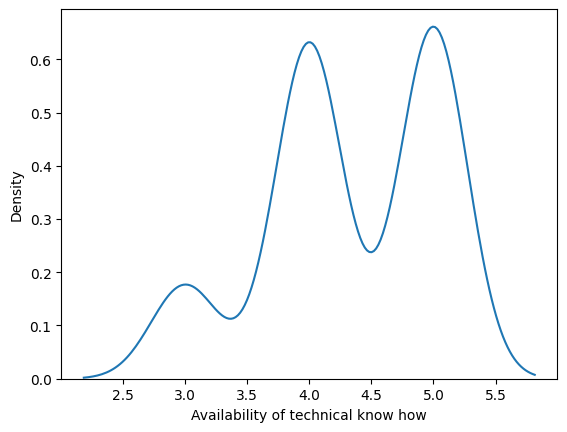

In [13]:
sns.kdeplot(df['Availability of technical know how'])

- some values are more likely to come while some not  see  rating between 3.5 go 4.5

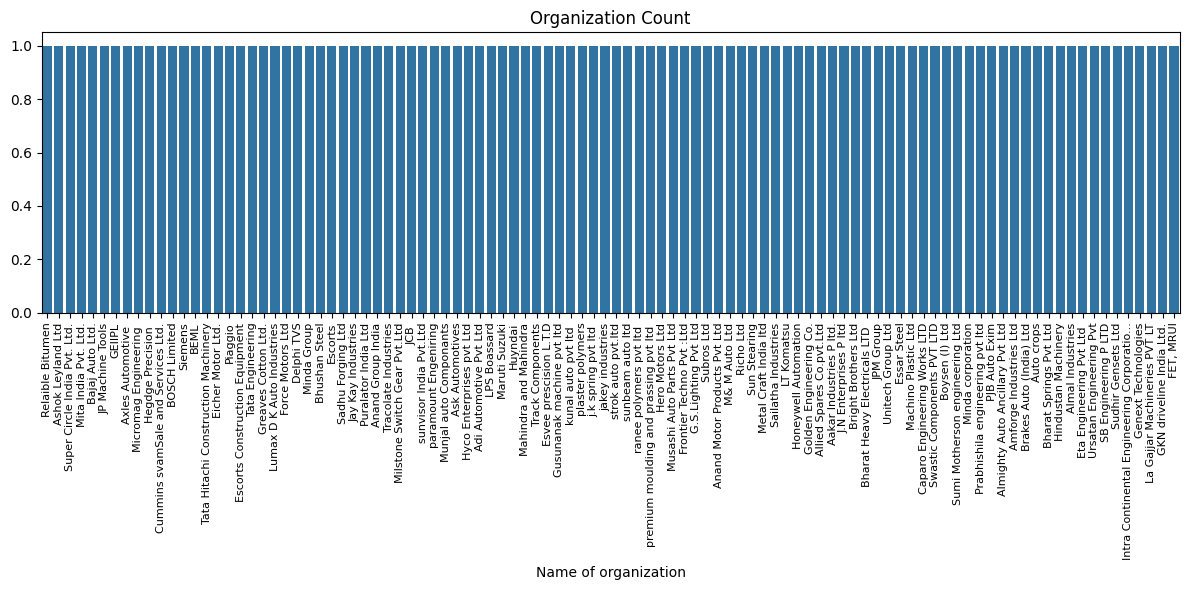

In [14]:
h = df['Name of organization'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=h.index, y=h.values)
plt.xticks(rotation=90, fontsize=8)
plt.title("Organization Count")
plt.tight_layout()
plt.show()

In [15]:
df_v=df.drop(columns=df.columns[:2])

In [16]:
df_v.corr()

,Types of machine,Maximum number of tools available,Maximum number of operation available,Tool magazine or tool turret capacity,Tool changing time,Type of operations to be done on machine,Variety of parts to be handled by the machine,Skills and versatility of workers,Setup or changeover time,Number of machines available in the system,...,Common tooling available,Space availability,Availability of technical know how,Flexibility of material handling system,Similarities of parts in the system,Design changes required in the product,Variety of products,Offline part programming preparation facility,Number of existing part families matching the new product design,Machine flexibility
Types of machine,1.000000,0.197701,0.170983,0.008683,0.117202,0.167806,0.273735,0.097301,0.182785,0.005550,...,0.171167,0.159486,0.166174,0.090715,0.234075,-0.052305,0.085963,0.093697,-0.008402,-0.041975
Maximum number of tools available,0.197701,1.000000,0.197349,0.140345,0.048707,0.170748,0.229416,0.170044,0.018581,-0.081406,...,0.035111,-0.046319,-0.073201,0.095035,0.102481,0.146122,-0.006037,-0.010708,0.150093,0.011471
Maximum number of operation available,0.170983,0.197349,1.000000,0.089698,0.110173,0.005827,0.144146,0.009806,0.174671,0.064914,...,0.251982,-0.087148,0.076625,0.085812,0.113766,0.132385,0.038986,0.021487,0.152714,0.115927
Tool magazine or tool turret capacity,0.008683,0.140345,0.089698,1.000000,-0.049355,0.216002,0.054378,0.203410,0.068486,0.174073,...,0.203123,0.111279,0.082282,0.036323,0.238223,-0.071001,0.008371,0.108505,0.191913,0.138262
Tool changing time,0.117202,0.048707,0.110173,-0.049355,1.000000,0.081659,-0.031846,0.190970,0.173333,-0.124951,...,0.110291,0.246906,0.157581,0.060355,0.080478,-0.090264,-0.093529,-0.013378,0.160200,0.252237
Type of operations to be done on machine,0.167806,0.170748,0.005827,0.216002,0.081659,1.000000,0.124846,0.008060,0.140708,0.058272,...,0.178956,0.206665,0.106707,-0.054601,0.152415,-0.010093,0.056181,-0.078669,0.080213,0.279620
Variety of parts to be handled by the machine,0.273735,0.229416,0.144146,0.054378,-0.031846,0.124846,1.000000,-0.043038,0.253780,0.070968,...,0.188028,0.034612,-0.039271,-0.005178,0.238242,0.180463,0.173687,0.070014,0.155079,0.105005
Skills and versatility of workers,0.097301,0.170044,0.009806,0.203410,0.190970,0.008060,-0.043038,1.000000,0.009993,0.010036,...,0.095413,-0.037488,0.093591,0.030308,0.192067,0.031067,0.114844,-0.018079,0.234223,0.024533
Setup or changeover time,0.182785,0.018581,0.174671,0.068486,0.173333,0.140708,0.253780,0.009993,1.000000,0.108883,...,0.178286,0.048497,0.169610,0.093608,0.283859,0.095952,-0.092334,0.197340,-0.030380,0.310545
Number of machines available in the system,0.005550,-0.081406,0.064914,0.174073,-0.124951,0.058272,0.070968,0.010036,0.108883,1.000000,...,-0.128076,-0.130010,0.031802,-0.287264,0.039983,0.214063,0.109976,-0.012777,0.057927,0.094899


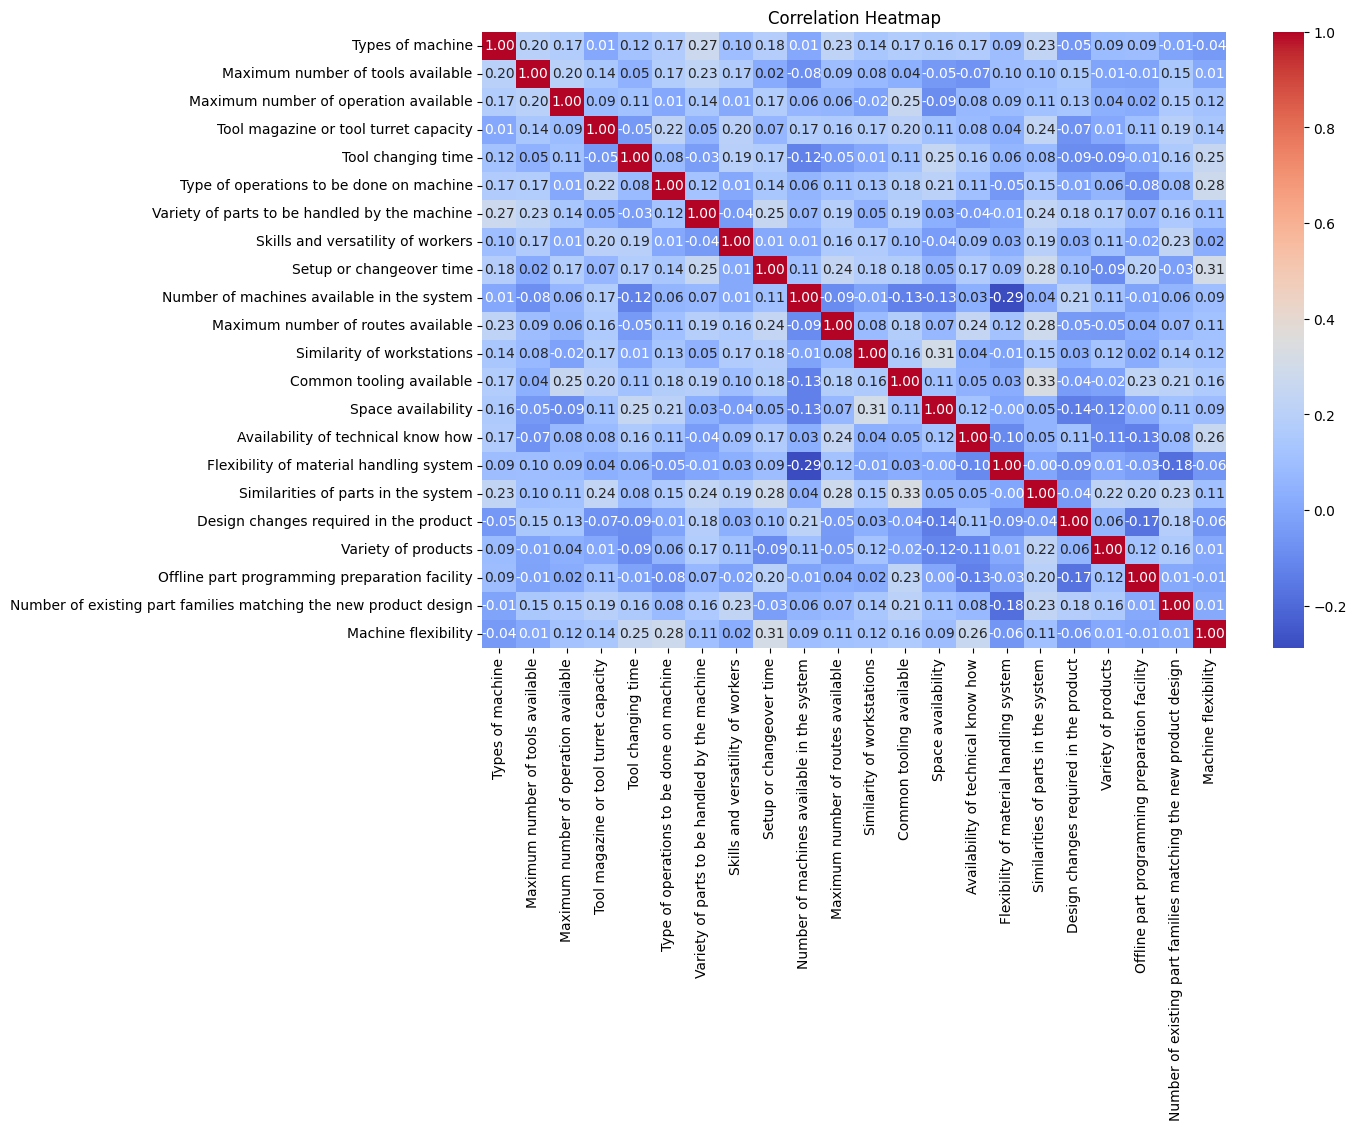

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df_v.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

- most of the values are strongly correlated because the values are discreate from 1 to 10 ranked data

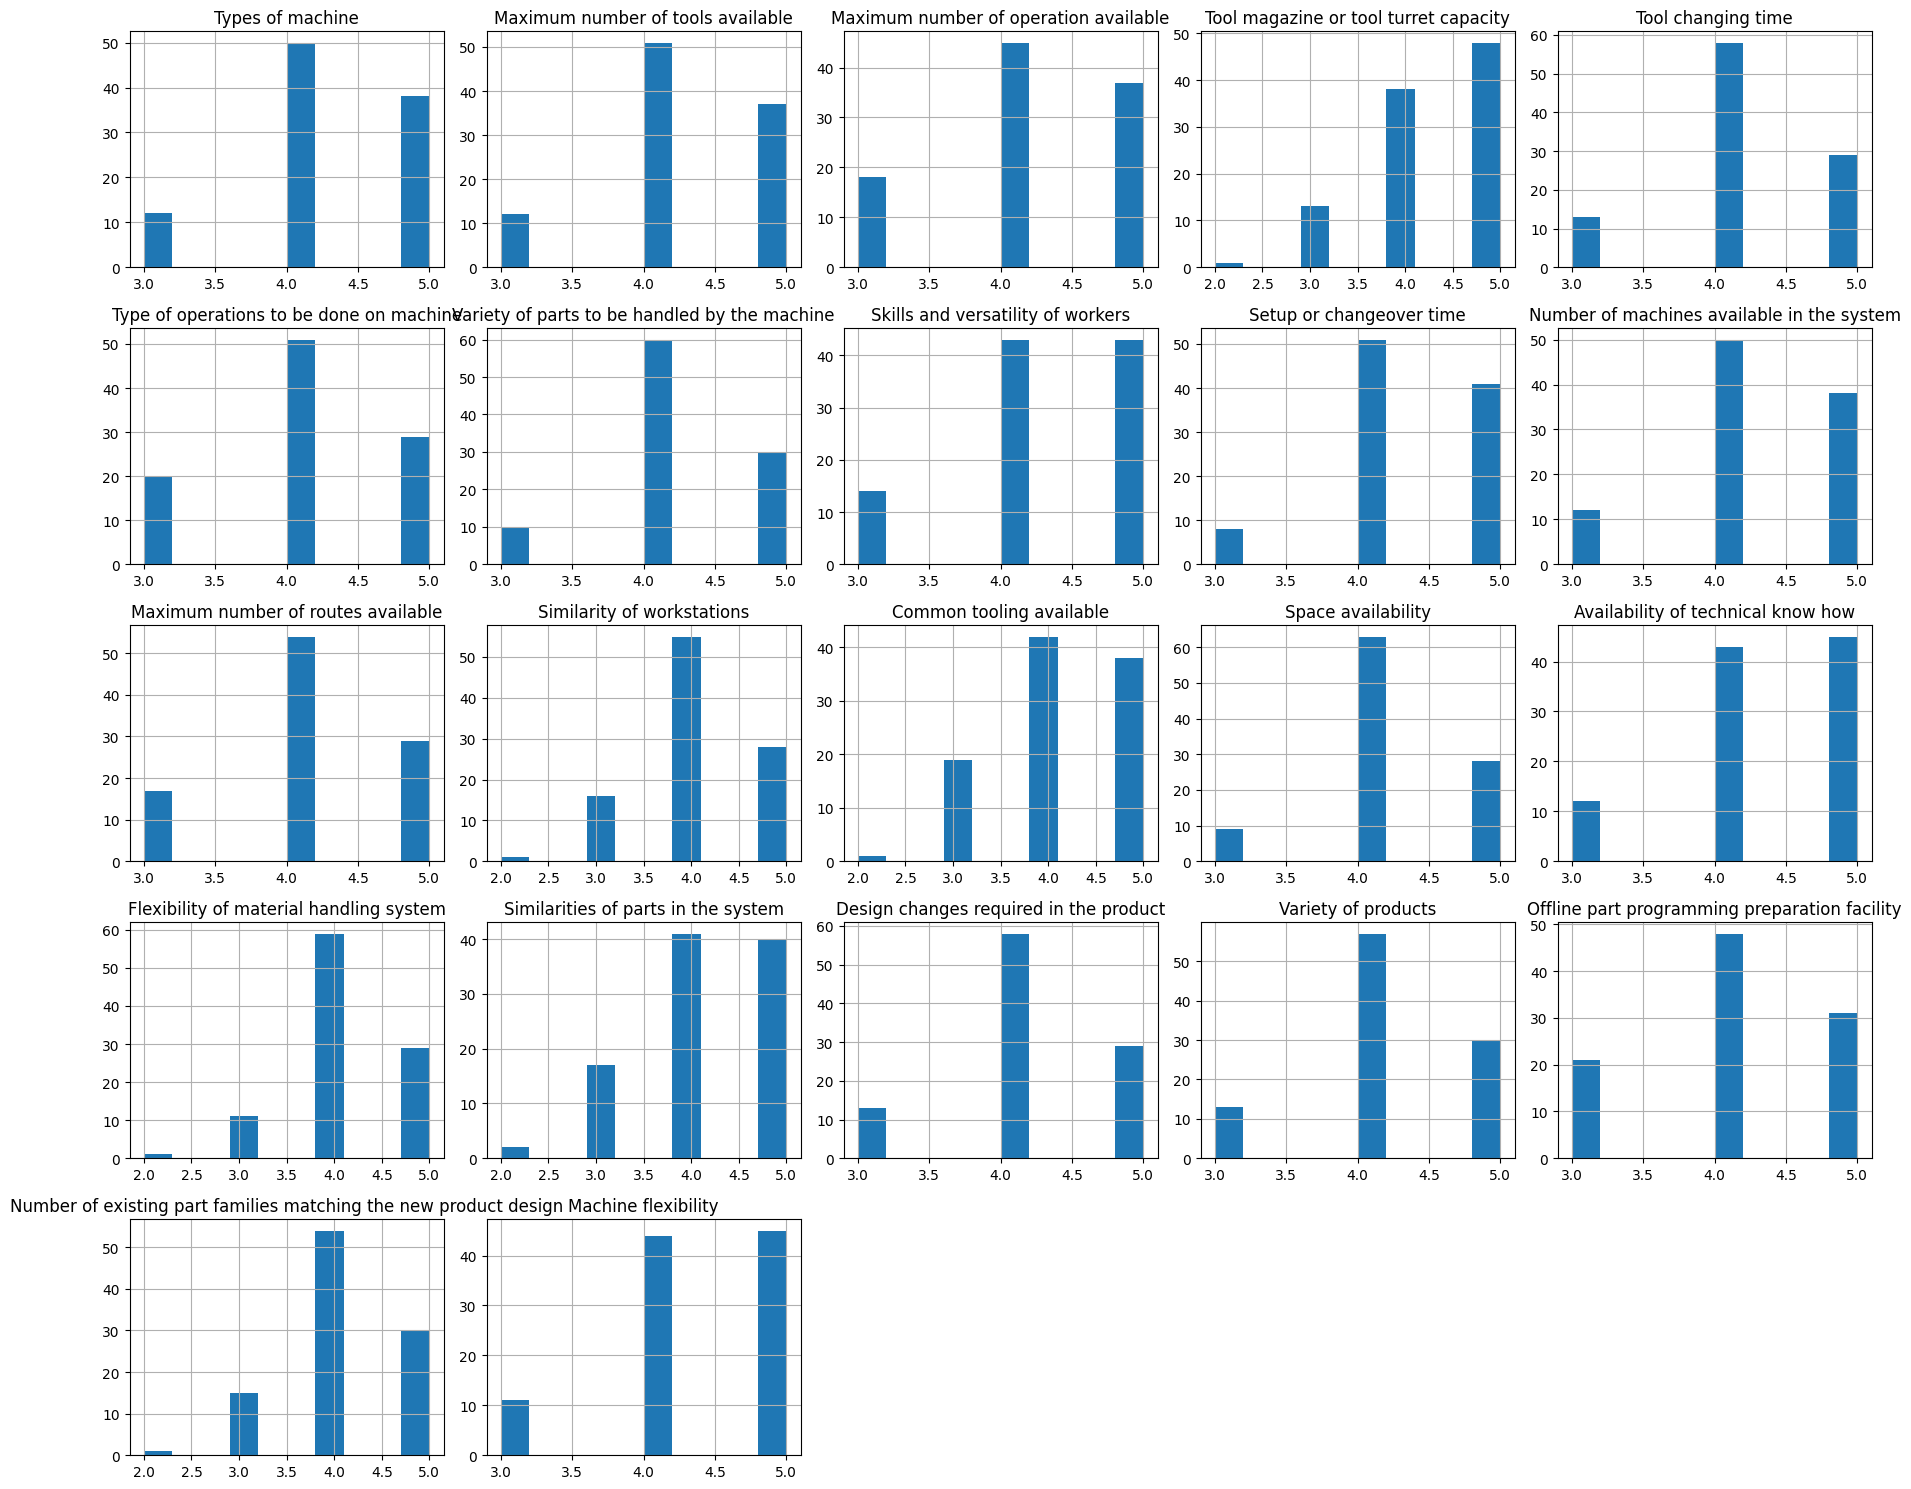

In [18]:
df.hist(figsize=(18,15))
plt.tight_layout()
plt.show()

- Destribution of rank values  some ranks values are not present if column as in tool changing time
- we can see only one value is near 14 heans seems to be anonymous outlier and same for all

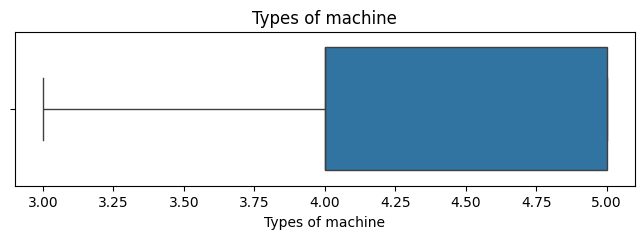

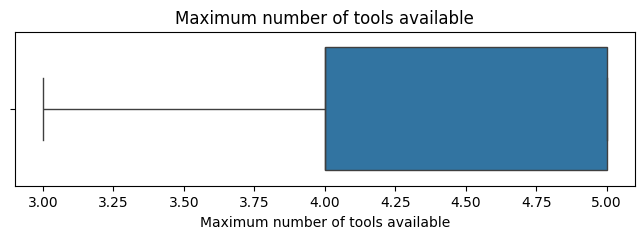

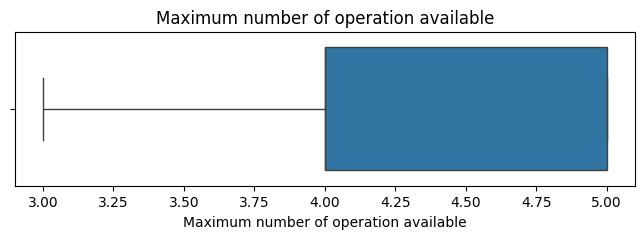

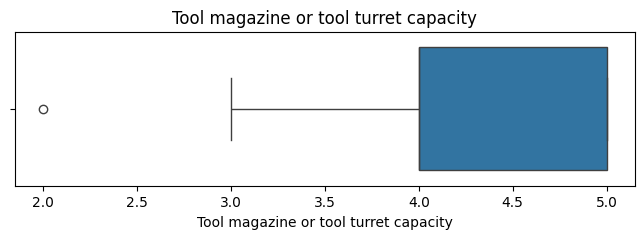

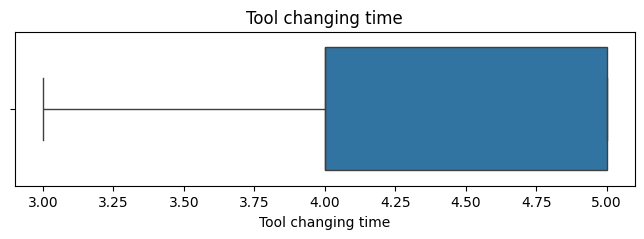

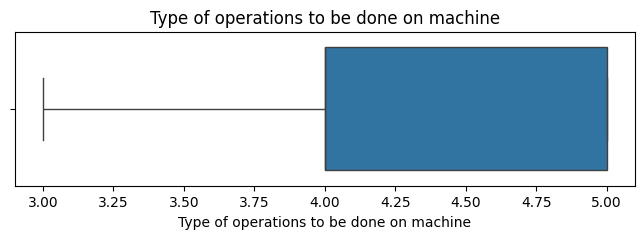

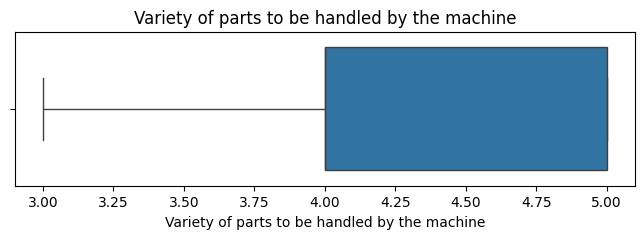

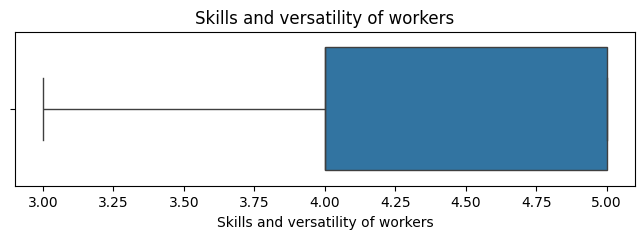

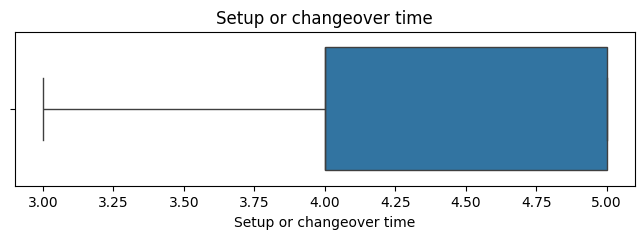

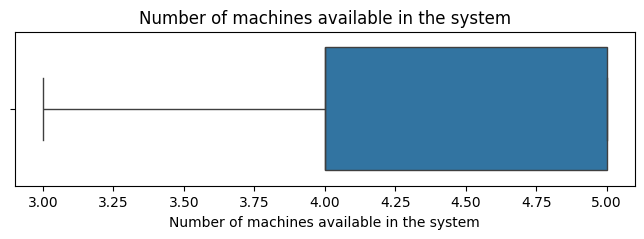

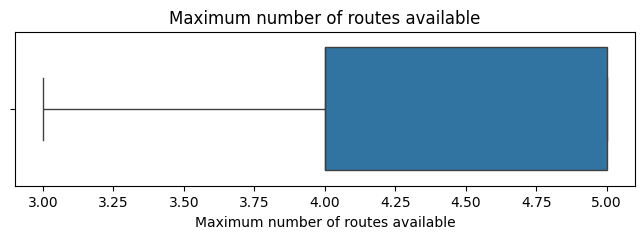

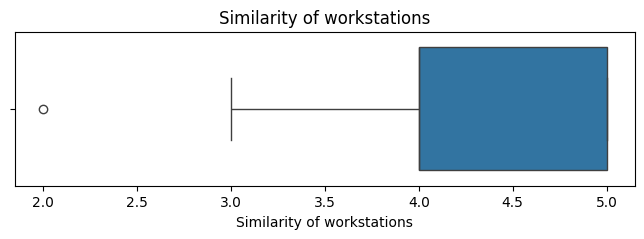

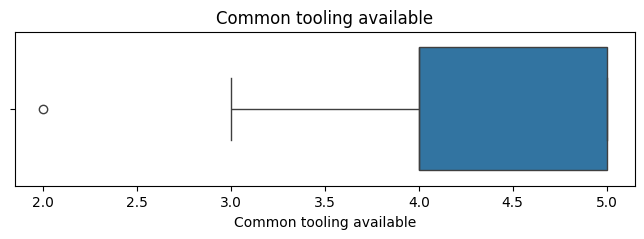

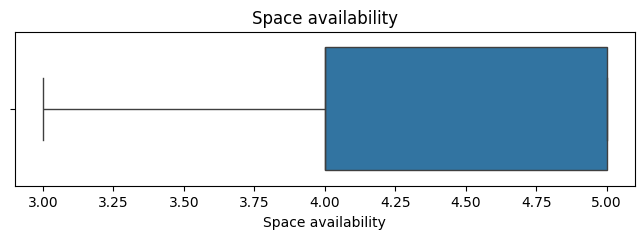

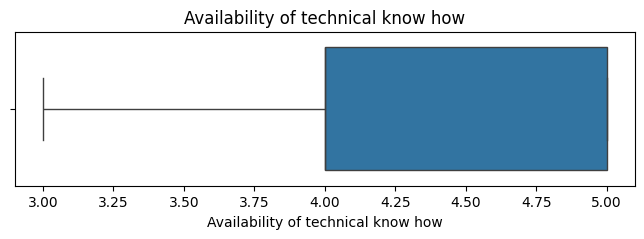

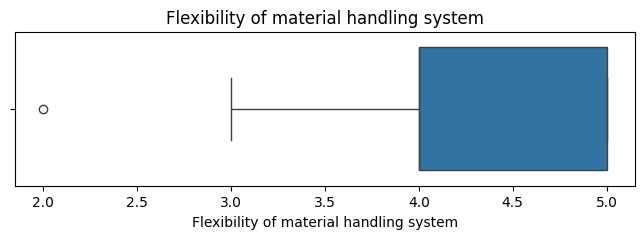

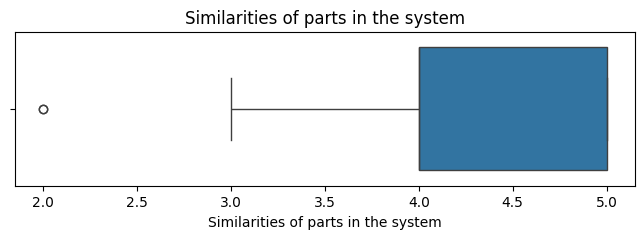

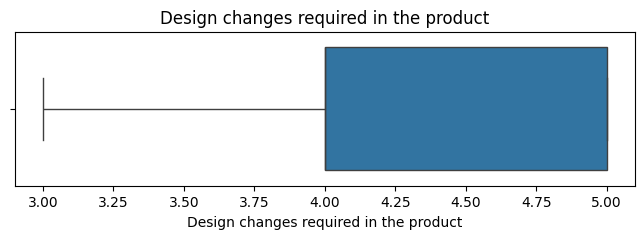

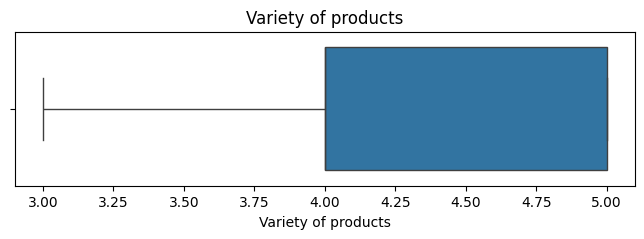

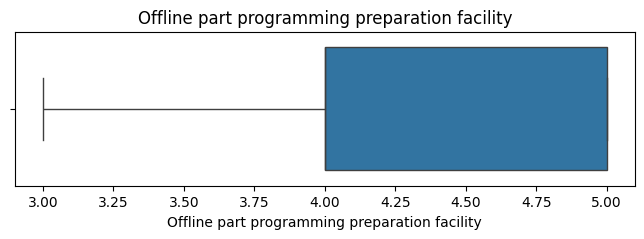

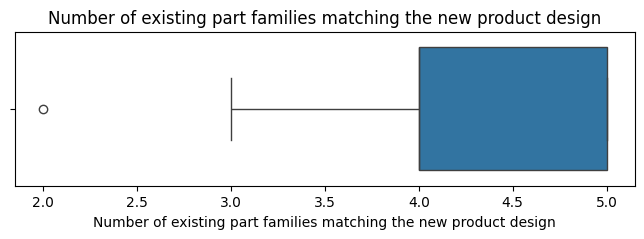

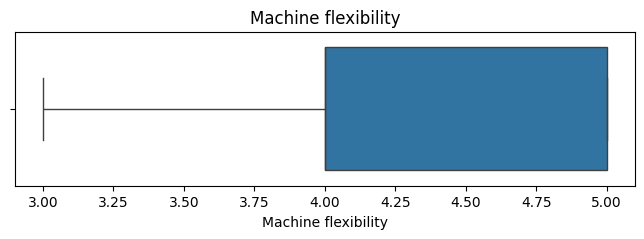

In [19]:
for col in df.select_dtypes(include='float').columns:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

(100, 2)


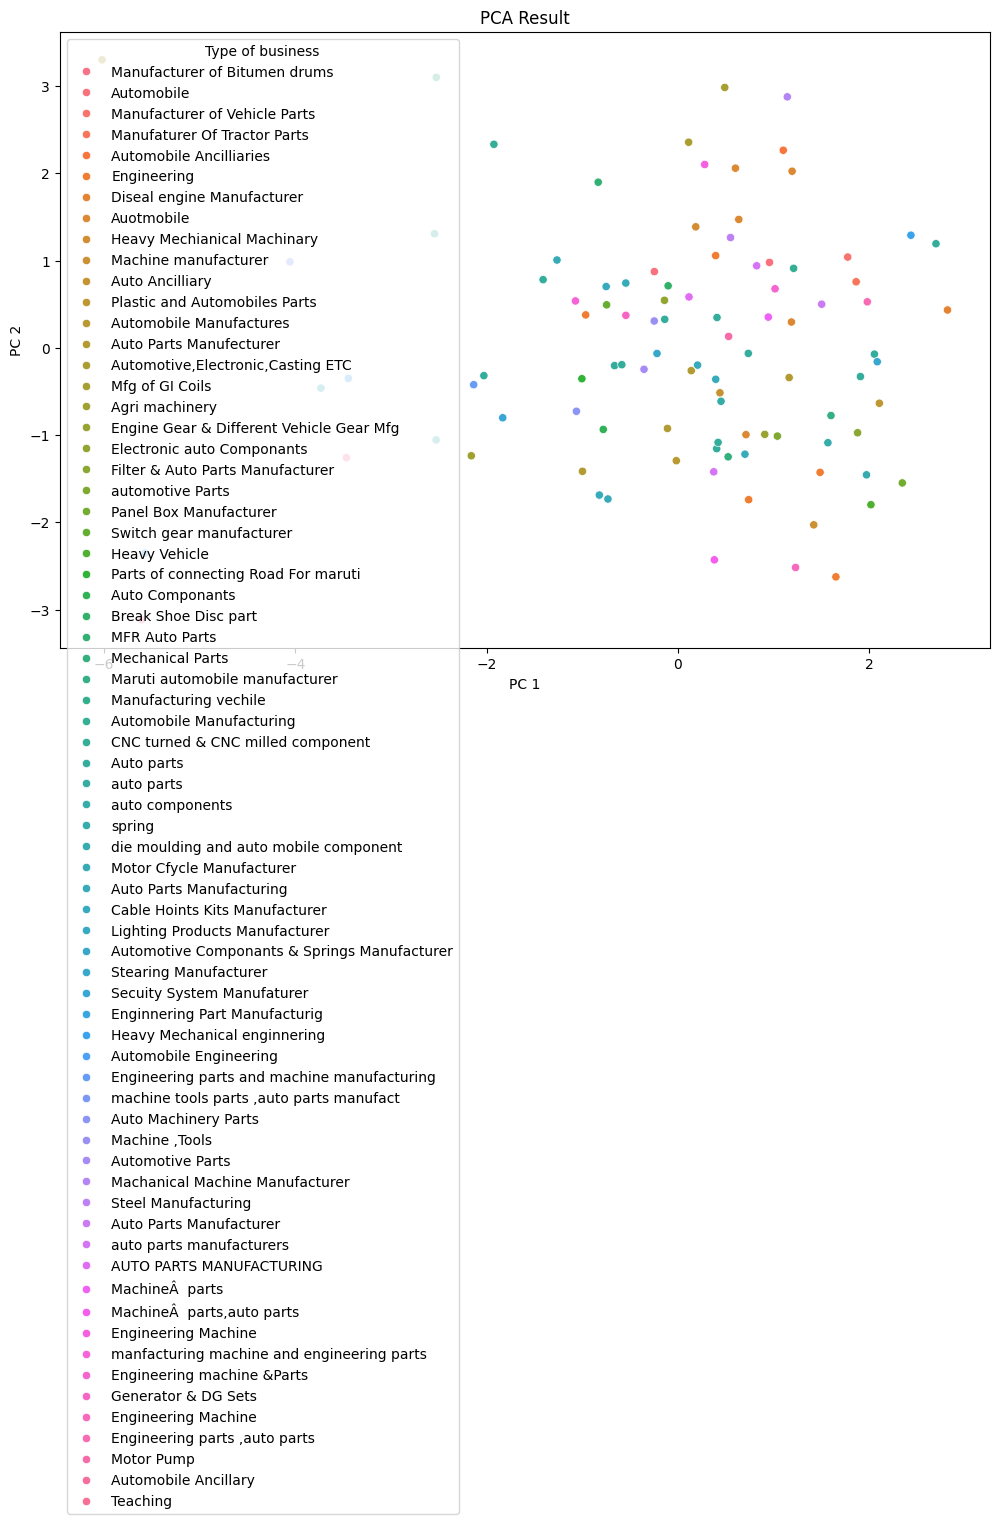

In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)

scaled_data = StandardScaler().fit_transform(df_v)

pca_result = pca.fit_transform(scaled_data)

print(pca_result.shape)

plt.figure(figsize=(12,8))

sns.scatterplot(
    x=pca_result[:,0],
    y=pca_result[:,1],
    hue=df['Type of business']
)

plt.title("PCA Result")
plt.xlabel("PC 1")
plt.ylabel("PC 2")

plt.show()

In [21]:
#breaking df_v along with sub categories to see wether there is a strong relation of sub features with felexibiity


amf=df[amf_cols]
arf=df[arf_cols]
apf=df[apf_cols]

print("AMF columns:", amf.shape)
print("ARF columns:", arf.shape)
print("APF columns:", apf.shape)

AMF columns: (100, 9)
ARF columns: (100, 8)
APF columns: (100, 5)


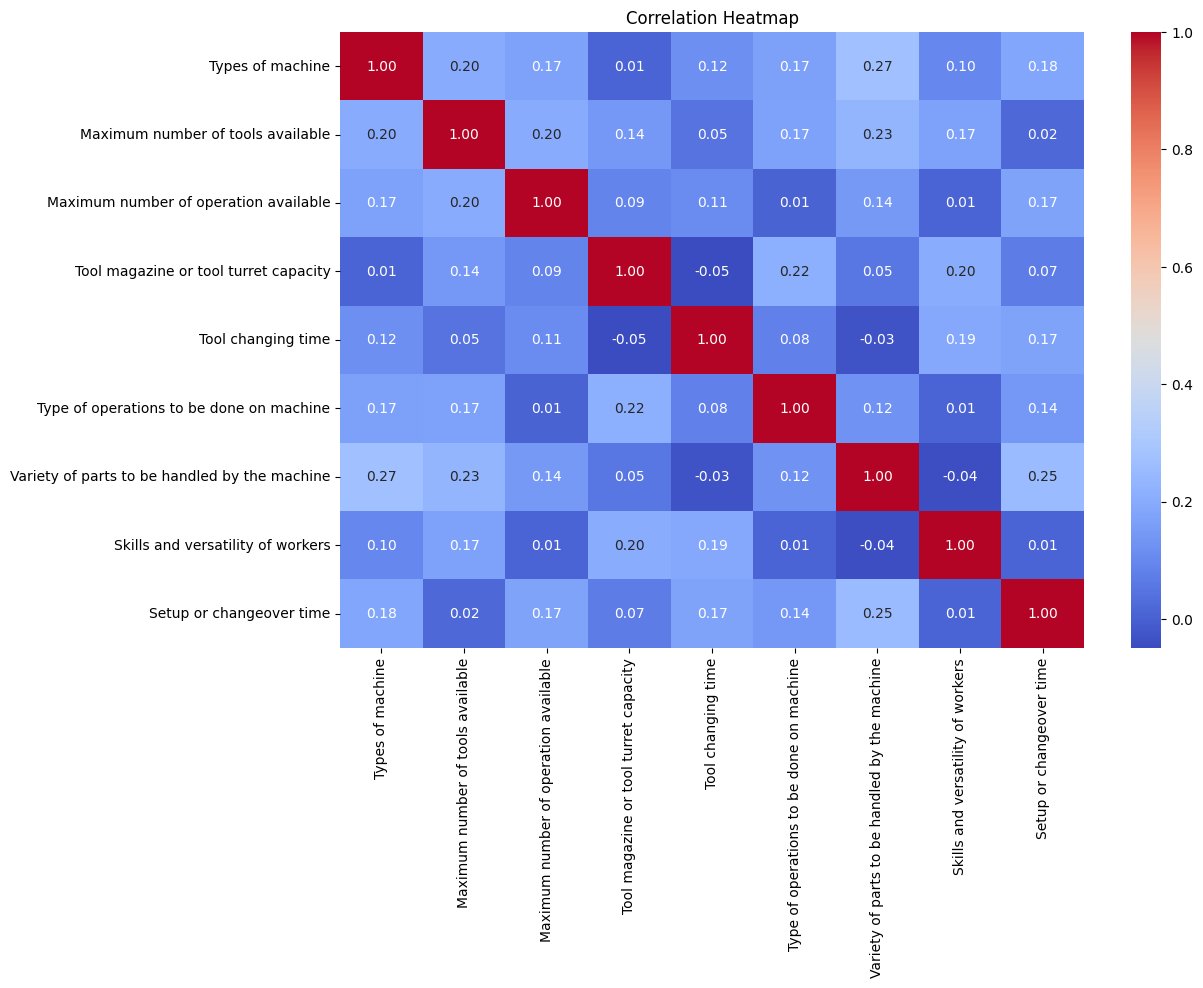

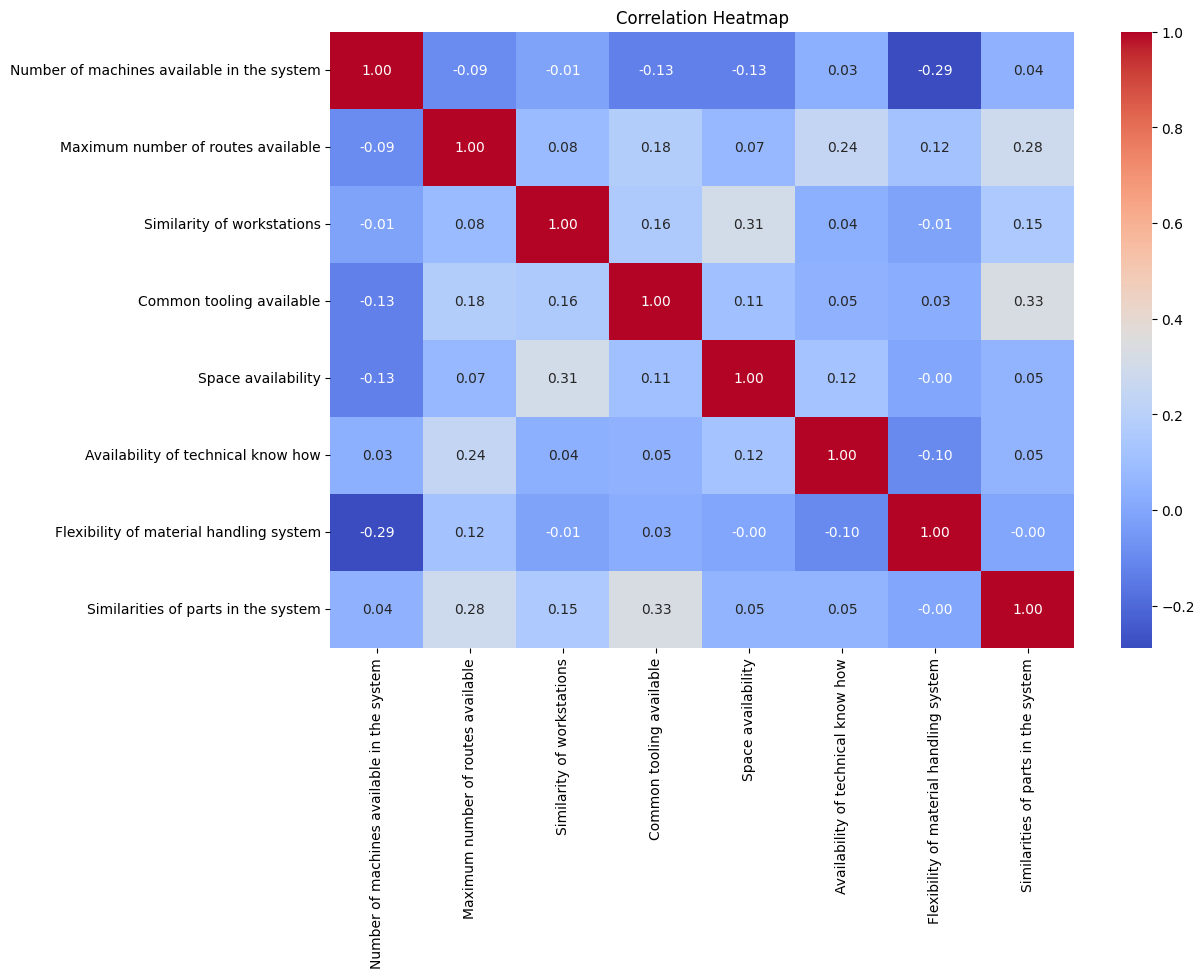

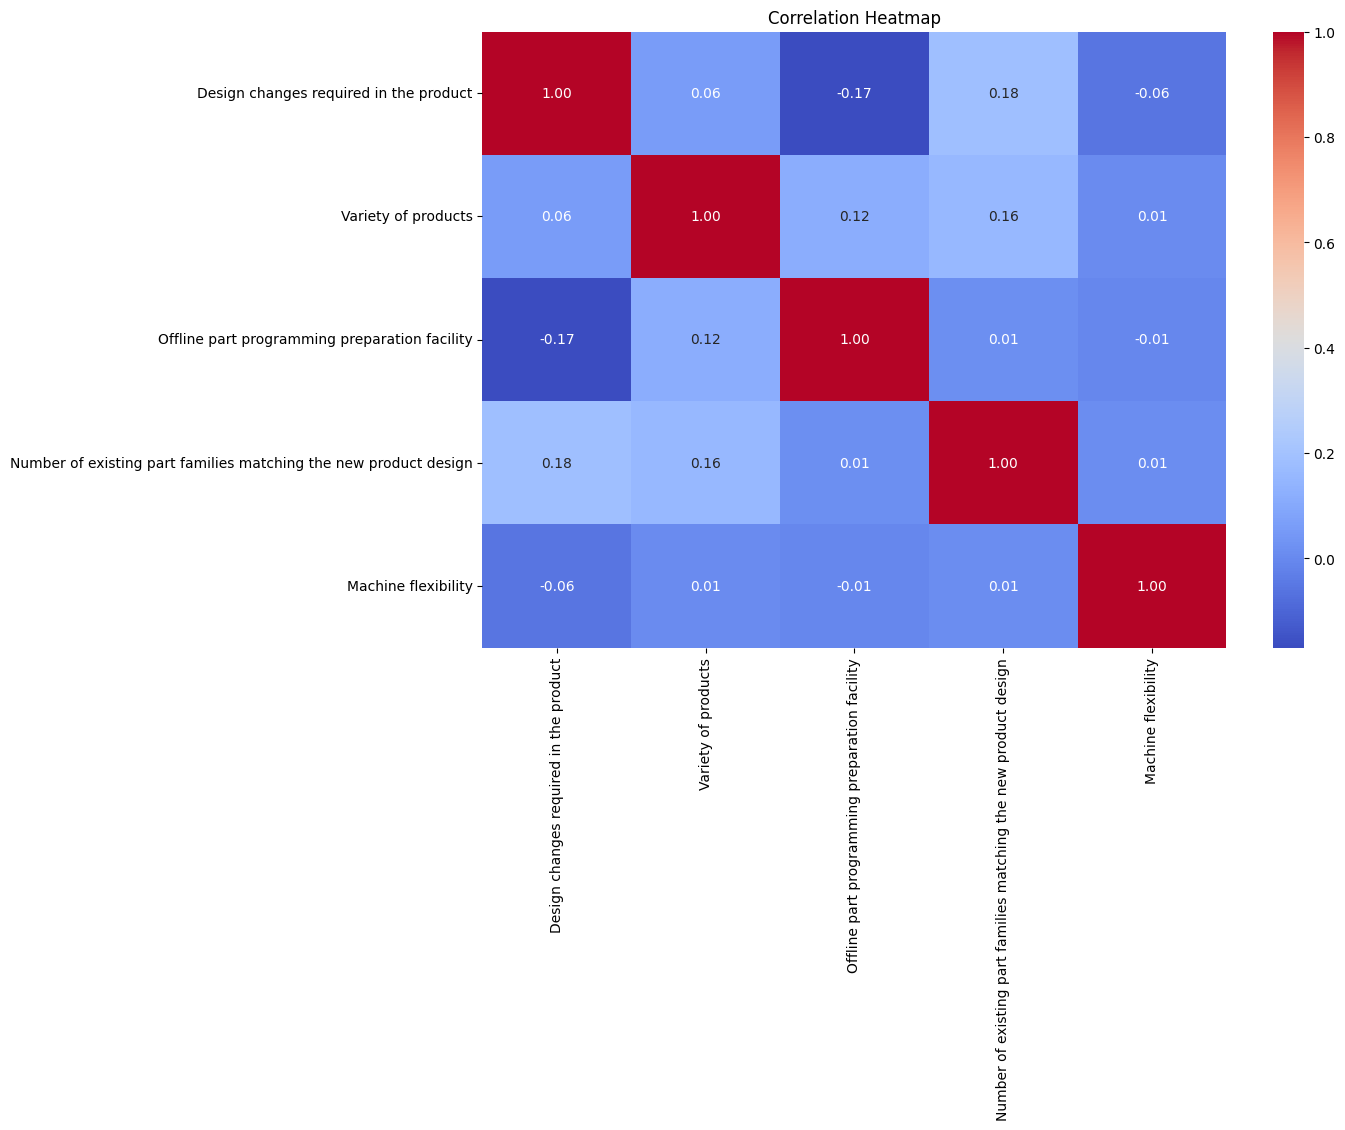

In [22]:
for df in [amf, arf, apf]:
    plt.figure(figsize=(12,8))
    sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

In [23]:
import pandas as pd

data_file_path = "data/survey1.xls"


df = pd.read_excel(
    data_file_path,
    header=[1,2],
    index_col=0
)

ddf = df.copy()

df.columns = [
    f"{str(a).strip()}&{str(b).strip()}"
    for a,b in df.columns
]

df.columns = [
    col.replace(".1", "")
       .replace(".2", "")
       .replace(".3", "")
       .replace(".4", "")
    for col in df.columns
]

df.columns = [
    "1.1. Name of organization",
    "1.2. Type of business"
] + list(df.columns[2:])


df.columns = df.columns.map(
    lambda x:
        x.replace("1.1.", "")
         .replace("1.2.", "")
         .strip()

        if "&" not in x

        else f'{"".join(w[0] for w in x.split("&")[0].split())}_ {x.split("&")[1].strip()}'
)
df

,Name of organization,Type of business,AMF_ Types of machine,AMF_ Maximum number of tools available,AMF_ Maximum number of operation available,AMF_ Tool magazine or tool turret capacity,AMF_ Tool changing time,AMF_ Type of operations to be done on machine,AMF_ Variety of parts to be handled by the machine,AMF_ Skills and versatility of workers,...,ARF_ Common tooling available,ARF_ Space availability,ARF_ Availability of technical know how,ARF_ Flexibility of material handling system,ARF_ Similarities of parts in the system,APF_ Design changes required in the product,APF_ Variety of products,APF_ Offline part programming preparation facility,APF_ Number of existing part families matching the new product design,APF_ Machine flexibility
1.0,Relaible Bitumen,Manufacturer of Bitumen drums,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,5.00000,...,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000
2.0,Ashok Leyland Ltd,Automobile,5.000000,4.000000,5.000000,5.000000,4.000000,3.000000,4.000000,5.00000,...,3.000000,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,3.000000,5.000000
3.0,Super Circle India Pvt. Ltd.,Manufacturer of Vehicle Parts,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,5.00000,...,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000
4.0,Mita India Pvt. Ltd.,Manufaturer Of Tractor Parts,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,5.00000,...,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000
5.0,Bajaj Auto Ltd.,Automobile Ancilliaries,5.000000,4.000000,5.000000,4.000000,4.000000,5.000000,5.000000,5.00000,...,5.000000,4.000000,5.000000,3.000000,4.000000,5.000000,4.000000,4.000000,5.000000,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102.0,GKN driveline India Ltd.,Manufacturing,5.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.00000,...,5.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,3.000000,4.000000,4.000000
103.0,"FET, MRUI",Teaching,4.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,4.00000,...,2.000000,4.000000,5.000000,4.000000,2.000000,4.000000,3.000000,4.000000,2.000000,4.000000
NaN,NaN,Average,4.271845,4.262136,4.194175,4.330097,4.174757,4.106796,4.203883,4.31068,...,4.194175,4.203883,4.320388,4.145631,4.184466,4.165049,4.184466,4.106796,4.126214,4.330097
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
amf_col=list(df.columns[0:2])+[col for col in df.columns if "AMF" in col]
amf=df[amf_col]


arf_col=list(df.columns[0:2])+[col for col in df.columns if "ARF" in col]
arf=df[arf_col]


apf_col=list(df.columns[0:2])+[col for col in df.columns if "APF" in col]
apf=df[apf_col]



In [25]:
amf

,Name of organization,Type of business,AMF_ Types of machine,AMF_ Maximum number of tools available,AMF_ Maximum number of operation available,AMF_ Tool magazine or tool turret capacity,AMF_ Tool changing time,AMF_ Type of operations to be done on machine,AMF_ Variety of parts to be handled by the machine,AMF_ Skills and versatility of workers,AMF_ Setup or changeover time
1.0,Relaible Bitumen,Manufacturer of Bitumen drums,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,5.00000,4.000000
2.0,Ashok Leyland Ltd,Automobile,5.000000,4.000000,5.000000,5.000000,4.000000,3.000000,4.000000,5.00000,4.000000
3.0,Super Circle India Pvt. Ltd.,Manufacturer of Vehicle Parts,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,5.00000,4.000000
4.0,Mita India Pvt. Ltd.,Manufaturer Of Tractor Parts,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,5.00000,4.000000
5.0,Bajaj Auto Ltd.,Automobile Ancilliaries,5.000000,4.000000,5.000000,4.000000,4.000000,5.000000,5.000000,5.00000,4.000000
...,...,...,...,...,...,...,...,...,...,...,...
102.0,GKN driveline India Ltd.,Manufacturing,5.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.00000,5.000000
103.0,"FET, MRUI",Teaching,4.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,4.00000,4.000000
NaN,NaN,Average,4.271845,4.262136,4.194175,4.330097,4.174757,4.106796,4.203883,4.31068,4.349515
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
arf

,Name of organization,Type of business,ARF_ Number of machines available in the system,ARF_ Maximum number of routes available,ARF_ Similarity of workstations,ARF_ Common tooling available,ARF_ Space availability,ARF_ Availability of technical know how,ARF_ Flexibility of material handling system,ARF_ Similarities of parts in the system
1.0,Relaible Bitumen,Manufacturer of Bitumen drums,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000
2.0,Ashok Leyland Ltd,Automobile,5.000000,4.000000,3.000000,3.000000,4.000000,5.000000,4.000000,5.000000
3.0,Super Circle India Pvt. Ltd.,Manufacturer of Vehicle Parts,4.000000,5.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000
4.0,Mita India Pvt. Ltd.,Manufaturer Of Tractor Parts,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,5.000000
5.0,Bajaj Auto Ltd.,Automobile Ancilliaries,5.000000,4.000000,4.000000,5.000000,4.000000,5.000000,3.000000,4.000000
...,...,...,...,...,...,...,...,...,...,...
102.0,GKN driveline India Ltd.,Manufacturing,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000,4.000000,5.000000
103.0,"FET, MRUI",Teaching,3.000000,4.000000,3.000000,2.000000,4.000000,5.000000,4.000000,2.000000
NaN,NaN,Average,4.262136,4.116505,4.126214,4.194175,4.203883,4.320388,4.145631,4.184466
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
apf

,Name of organization,Type of business,APF_ Design changes required in the product,APF_ Variety of products,APF_ Offline part programming preparation facility,APF_ Number of existing part families matching the new product design,APF_ Machine flexibility
1.0,Relaible Bitumen,Manufacturer of Bitumen drums,4.000000,5.000000,4.000000,5.000000,4.000000
2.0,Ashok Leyland Ltd,Automobile,4.000000,5.000000,4.000000,3.000000,5.000000
3.0,Super Circle India Pvt. Ltd.,Manufacturer of Vehicle Parts,4.000000,5.000000,5.000000,5.000000,4.000000
4.0,Mita India Pvt. Ltd.,Manufaturer Of Tractor Parts,4.000000,5.000000,4.000000,5.000000,4.000000
5.0,Bajaj Auto Ltd.,Automobile Ancilliaries,5.000000,4.000000,4.000000,5.000000,3.000000
...,...,...,...,...,...,...,...
102.0,GKN driveline India Ltd.,Manufacturing,5.000000,5.000000,3.000000,4.000000,4.000000
103.0,"FET, MRUI",Teaching,4.000000,3.000000,4.000000,2.000000,4.000000
NaN,NaN,Average,4.165049,4.184466,4.106796,4.126214,4.330097
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
print(amf.isnull().sum())
print(arf.isnull().sum())
print(apf.isnull().sum())

Name of organization                                  3
Type of business                                      3
AMF_ Types of machine                                 1
AMF_ Maximum number of tools available                1
AMF_ Maximum number of operation available            1
AMF_ Tool magazine or tool turret capacity            1
AMF_ Tool changing time                               1
AMF_ Type of operations to be done on machine         1
AMF_ Variety of parts to be handled by the machine    1
AMF_ Skills and versatility of workers                1
AMF_ Setup or changeover time                         1
dtype: int64
Name of organization                               3
Type of business                                   3
ARF_ Number of machines available in the system    1
ARF_ Maximum number of routes available            1
ARF_ Similarity of workstations                    1
ARF_ Common tooling available                      1
ARF_ Space availability                            1


In [29]:
# amf.ffill(inplace=True)
# arf.ffill(inplace=True)
# apf.ffill(inplace=True)

amf.dropna(inplace=True)
arf.dropna(inplace=True)
apf.dropna(inplace=True)

In [30]:
print(amf.isnull().sum())
print(arf.isnull().sum())
print(apf.isnull().sum())

Name of organization                                  0
Type of business                                      0
AMF_ Types of machine                                 0
AMF_ Maximum number of tools available                0
AMF_ Maximum number of operation available            0
AMF_ Tool magazine or tool turret capacity            0
AMF_ Tool changing time                               0
AMF_ Type of operations to be done on machine         0
AMF_ Variety of parts to be handled by the machine    0
AMF_ Skills and versatility of workers                0
AMF_ Setup or changeover time                         0
dtype: int64
Name of organization                               0
Type of business                                   0
ARF_ Number of machines available in the system    0
ARF_ Maximum number of routes available            0
ARF_ Similarity of workstations                    0
ARF_ Common tooling available                      0
ARF_ Space availability                            0


In [31]:
data_frames = []
actual_labels = {}

current_idx = 0

acutal_legends={
    0:"AMF",
    1:"ARF",
    2:"APF"
}
for df in [amf, arf, apf]:

    n_components = 4

    pca = PCA(n_components=n_components)

    scaled_data = StandardScaler().fit_transform(df.select_dtypes('float'))

    pca_result = pca.fit_transform(scaled_data)

    columns = [f"PC{i+1}" for i in range(n_components)]

    pca_df = pd.DataFrame(data=pca_result, columns=columns)

    pca_df.index = range(current_idx, current_idx + len(df))

    data_frames.append(pca_df)

    # assign labels
    for idx in pca_df.index:

        if df.columns.equals(amf.columns):
            actual_labels[idx] = 0

        elif df.columns.equals(arf.columns):
            actual_labels[idx] = 1

        elif df.columns.equals(apf.columns):
            actual_labels[idx] = 2

    current_idx += len(df)

In [32]:
merged_df = pd.concat(data_frames, axis=0)

merged_df.head()

,PC1,PC2,PC3,PC4
0,0.630548,1.878592,-0.880908,0.262952
1,0.193762,0.699640,0.324119,-1.625007
2,0.630548,1.878592,-0.880908,0.262952
3,0.630548,1.878592,-0.880908,0.262952
4,1.512908,-0.248199,-0.231706,-0.191785



Cluster Mapping:
{np.int32(0): 'AMF', np.int32(1): 'ARF', np.int32(2): 'APF'}


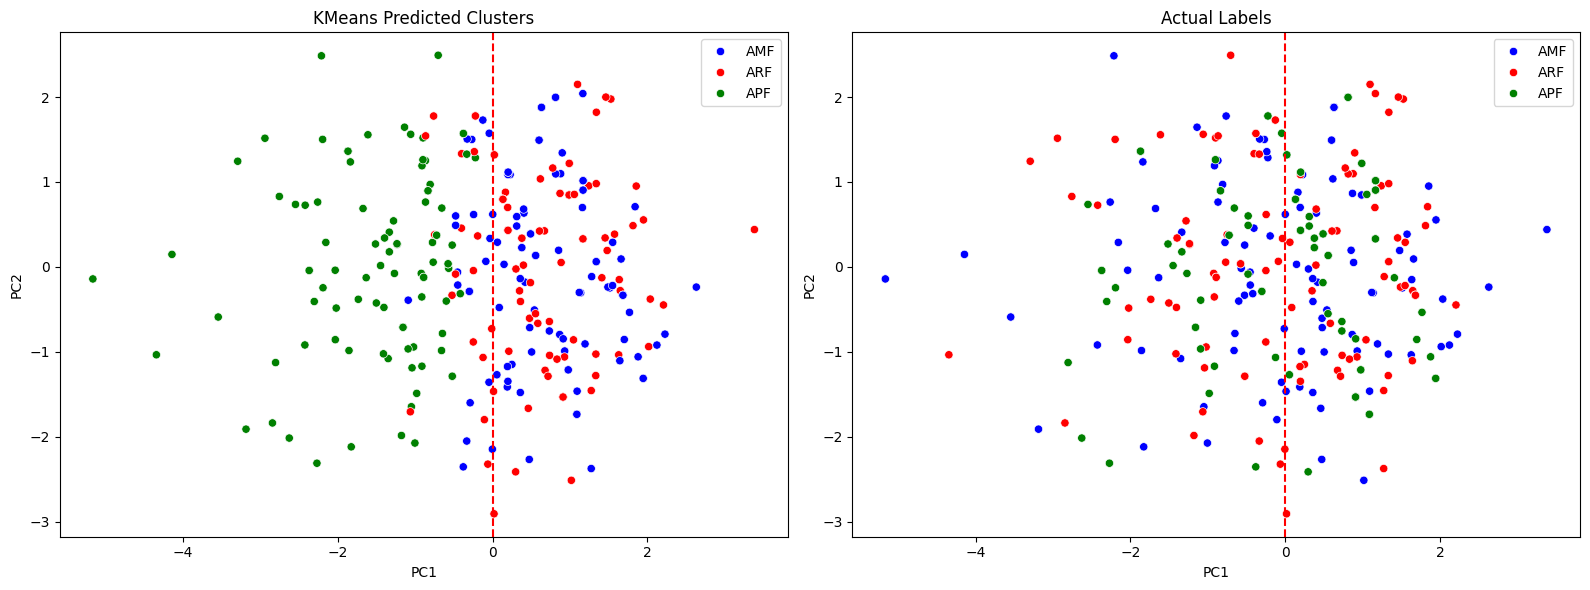

In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

labels = kmeans.fit_predict(merged_df)


actual_named_labels = []

for idx in range(len(merged_df)):

    if 0 <= idx < len(amf):
        actual_named_labels.append("AMF")

    elif len(amf) <= idx < len(amf) + len(arf):
        actual_named_labels.append("ARF")

    else:
        actual_named_labels.append("APF")


# unique cluster mapping

cluster_name_map = {}

used_names = set()

for cluster in set(labels):

    cluster_indices = [
        idx for idx, c in enumerate(labels)
        if c == cluster
    ]

    assigned = False

    for idx in cluster_indices:

        dataset_name = actual_named_labels[idx]

        # unique label not used yet
        if dataset_name not in used_names:

            cluster_name_map[cluster] = dataset_name

            used_names.add(dataset_name)

            assigned = True

            break

    # fallback if all already used
    if not assigned:

        cluster_name_map[cluster] = actual_named_labels[
            cluster_indices[0]
        ]


pred_named_labels = [
    cluster_name_map[x]
    for x in labels
]

print("\nCluster Mapping:")
print(cluster_name_map)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,6)
)

color_map = {
    "AMF": "blue",
    "ARF": "red",
    "APF": "green"
}
# Predicted
sns.scatterplot(
    x=merged_df["PC1"],
    y=merged_df["PC2"],
    hue=pred_named_labels,
    palette=color_map,
    ax=axes[0]
)

axes[0].set_title("KMeans Predicted Clusters")
axes[0].axvline(x=0,color='red', linestyle='--')


# Actual
sns.scatterplot(
    x=merged_df["PC1"],
    y=merged_df["PC2"],
    hue=actual_named_labels,
    palette=color_map,
    ax=axes[1]
)

axes[1].set_title("Actual Labels")
axes[1].axvline(x=0,color='red', linestyle='--')

plt.tight_layout()

plt.show()

In [34]:
df.columns

Index(['Name of organization', 'Type of business',
       'APF_ Design changes required in the product',
       'APF_ Variety of products',
       'APF_ Offline part programming preparation facility',
       'APF_ Number of existing part families matching the new product design',
       'APF_ Machine flexibility'],
      dtype='str')

In [35]:
[col for col in df.columns if col.startswith("AMF_")]

[]

In [36]:
amf

,Name of organization,Type of business,AMF_ Types of machine,AMF_ Maximum number of tools available,AMF_ Maximum number of operation available,AMF_ Tool magazine or tool turret capacity,AMF_ Tool changing time,AMF_ Type of operations to be done on machine,AMF_ Variety of parts to be handled by the machine,AMF_ Skills and versatility of workers,AMF_ Setup or changeover time
1.0,Relaible Bitumen,Manufacturer of Bitumen drums,4.0,5.0,4.0,5.0,4.0,5.0,4.0,5.0,4.0
2.0,Ashok Leyland Ltd,Automobile,5.0,4.0,5.0,5.0,4.0,3.0,4.0,5.0,4.0
3.0,Super Circle India Pvt. Ltd.,Manufacturer of Vehicle Parts,4.0,5.0,4.0,5.0,4.0,5.0,4.0,5.0,4.0
4.0,Mita India Pvt. Ltd.,Manufaturer Of Tractor Parts,4.0,5.0,4.0,5.0,4.0,5.0,4.0,5.0,4.0
5.0,Bajaj Auto Ltd.,Automobile Ancilliaries,5.0,4.0,5.0,4.0,4.0,5.0,5.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
99.0,Genext Technologies,"Engineering parts ,auto parts",4.0,4.0,5.0,5.0,4.0,3.0,5.0,4.0,5.0
100.0,La Gajjar Machineries PVT LT,Motor Pump,5.0,4.0,3.0,4.0,4.0,5.0,4.0,3.0,4.0
101.0,GKN driveline India Ltd.,Automobile Ancillary,4.0,3.0,3.0,2.0,4.0,3.0,4.0,4.0,4.0
102.0,GKN driveline India Ltd.,Manufacturing,5.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0,5.0


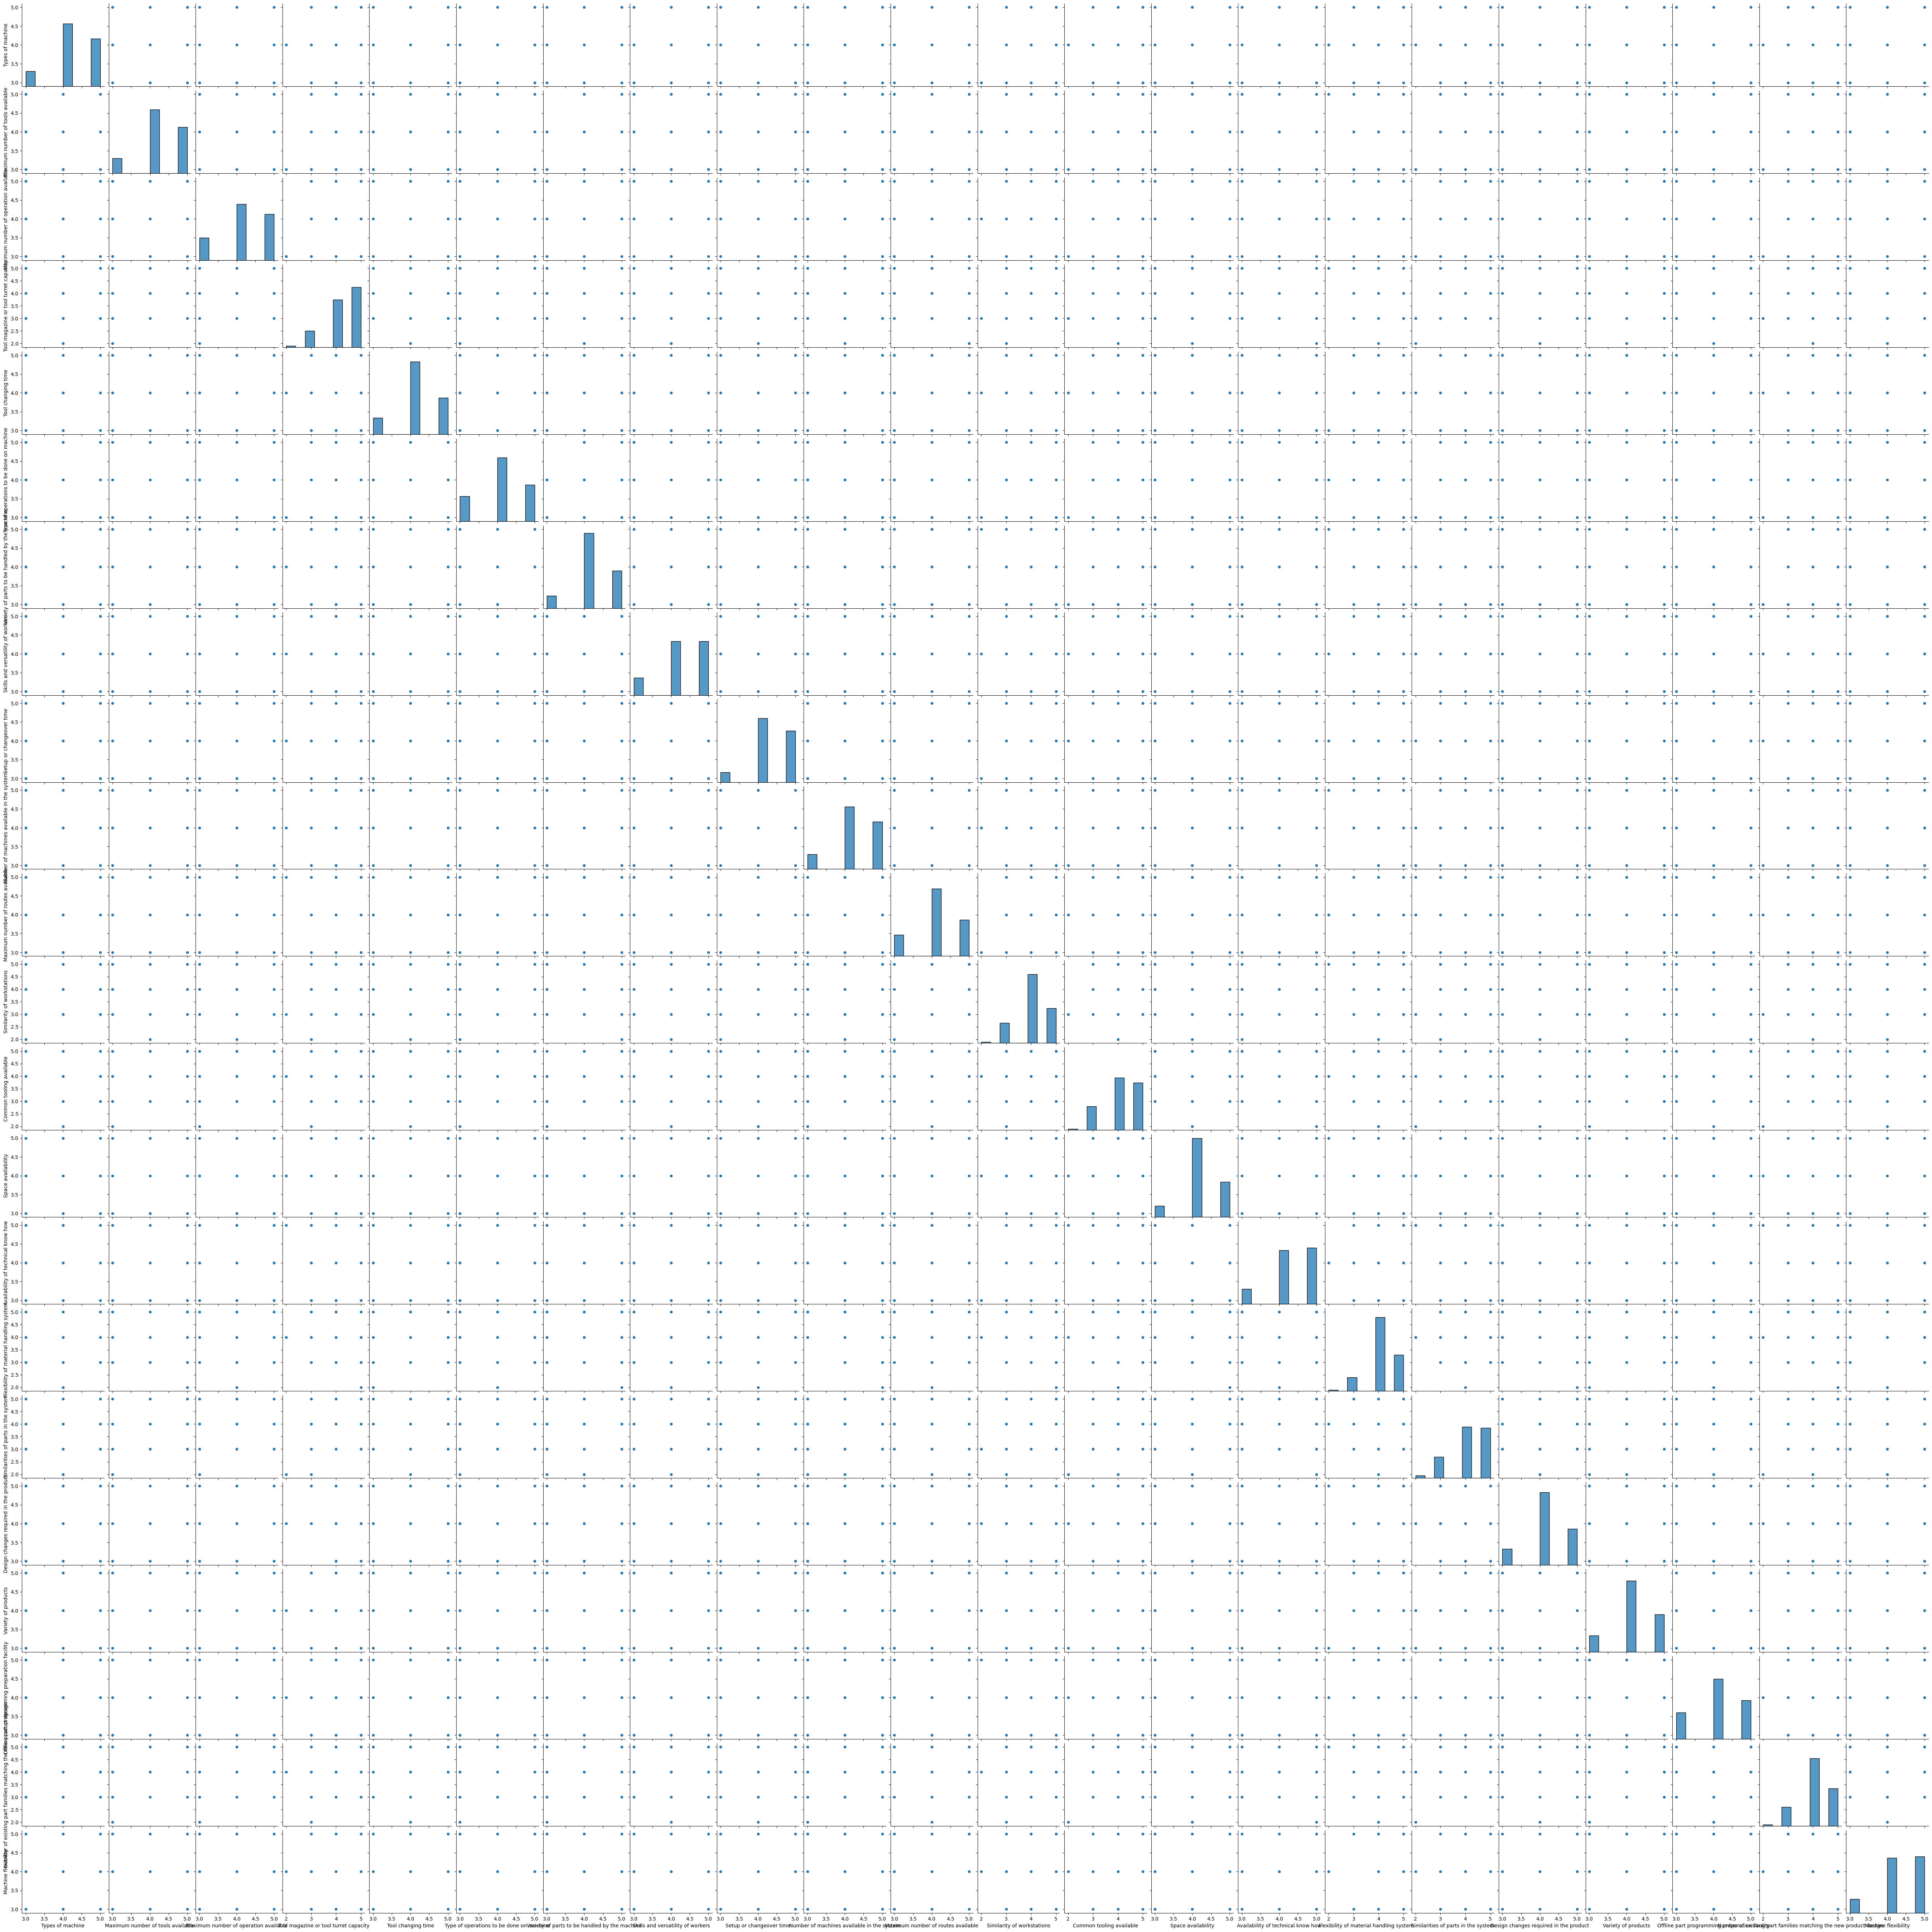

In [37]:
sns.pairplot(df_v)

In [38]:
from sklearn.preprocessing import MinMaxScaler

sc=MinMaxScaler()
numerical_df=df.select_dtypes(include=['number'])

scaled_cols=sc.fit_transform(numerical_df)
df[numerical_df.columns]=scaled_cols

In [39]:

!pip install scikit-learn --quiet
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
from sklearn.metrics.pairwise import cosine_similarity


def reconstruction_error(X, n_components=1):
    """This first compress and then reproject data to original one"""
    # scaler = MinMaxScaler()
    # X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    X_reconstructed = pca.inverse_transform(X_pca)

    return np.mean((X - X_reconstructed) ** 2)

def get_pc1(X, n_components=1):
    """The PCA component that one unit vector which has high variance ratio"""
    # scaler = MinMaxScaler()
    # X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=n_components)
    pca.fit(X)

    return pca.components_[0]

def leave_one_out_pca(data_frame: pd.DataFrame, beta=0.7):
    """This First Construct Complete data score then remove a column find out diference and then gives scores"""

    scores = {}

    # -------- FULL DATA BASELINE --------
    E_full = reconstruction_error(data_frame, n_components=1)
    pc1_full = get_pc1(data_frame)

    for col in data_frame.columns:

        print(f"Processing column: {col}")

        df_drop = data_frame.drop(columns=[col])

        if df_drop.shape[1] < 1:
            scores[col] = 0
            continue

        E_i = reconstruction_error(df_drop, n_components=1)

        recon_score = E_i - E_full


        pc1_i = get_pc1(df_drop)

        min_len = min(len(pc1_full), len(pc1_i))
        cos_sim = cosine_similarity(
            pc1_full[:min_len].reshape(1, -1),
            pc1_i[:min_len].reshape(1, -1)
        )[0][0]

        direction_score = 1 - cos_sim


        score = beta * recon_score + (1 - beta) * direction_score

        scores[col] = score

    return scores


# ========================== leave_one_out K-mean ============================================
def plot_kmeans_clusters(X, labels,file_path,score):
    
    # # reducing to 2D
    # pca = PCA(n_components=2)
    # X_2d = pca.fit_transform(X)

    # plt.figure(figsize=(8,6))

    # plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', s=50)

    # plt.title("KMeans Clusters (PCA Projection)")
    # plt.xlabel("PCA 1")
    # plt.ylabel("PCA 2")
    # plt.text(0.98, 0.98, f"Score: {score}",
    #      transform=plt.gca().transAxes,
    #      fontsize=12,
    #      va='top',
    #      ha='right')
    # # plt.legend()
    # plt.colorbar(label="Cluster")
    # plt.savefig(file_path)
    # plt.close()
    # # plt.show()
    pass

def find_best_k(df, k_range=(2, 10)):
    # X = StandardScaler().fit_transform(df)

    best_k = 2
    best_score = -1

    for k in range(k_range[0], k_range[1] + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(df)

        score = silhouette_score(df, labels)

        if score > best_score:
            best_score = score
            best_k = k

    return best_k

def feature_importance_kmeans(df):
    """if after removing features clusters are not overlaping and clear (high silhouette score) then feature is not important """
    # scaler = StandardScaler()
    # X_scaled_full = scaler.fit_transform(df)

    print("Finding best k")
    best_k=find_best_k(df=df)
    print("found best k ", best_k)
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels_full = kmeans.fit_predict(df)

    base_score = silhouette_score(df, labels_full)

    m = {}

    fig_folder="./output/fig"

    os.makedirs(fig_folder, exist_ok=True)

    for col in df.columns:
        X_drop = df.drop(columns=[col])

        # X_scaled = scaler.fit_transform(X_drop)

        kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_drop)



        score = silhouette_score(X_drop, labels)

        plot_kmeans_clusters(X_drop, labels, os.path.join(fig_folder,f"{col}_Cluster.png"),score=score)

        m[col] = base_score - score

    return m   



# ============================== leave one out dbscan ========================================

def feature_importance_dbscan(df, eps=0.5, min_sample=5):

    fig_folder = "./output/fig"
    os.makedirs(fig_folder, exist_ok=True)

    # -------- Safe Silhouette --------
    def safe_silhouette(X, labels):
        unique = set(labels) - {-1}  # noise removing step

        if len(unique) < 2:
            return 0

        return silhouette_score(X, labels)

    db = DBSCAN(eps=eps, min_samples=min_sample)
    labels_full = db.fit_predict(df)

    base_score = safe_silhouette(df, labels_full)

    m = {}

    for col in df.columns:

        X_drop = df.drop(columns=[col])

        db = DBSCAN(eps=eps, min_samples=min_sample)
        labels = db.fit_predict(X_drop)

        score = safe_silhouette(X_drop, labels)

        plot_kmeans_clusters(
            X_drop,
            labels,
            os.path.join(fig_folder, f"{col}_Cluster.png"),
            score=score
        )

        m[col] = base_score - score

    return m






# ========================== Entropy Score =========================================
def entropy_calculation(data_frame: pd.DataFrame):
    """calculates entropy of the column if 
    col have only 55555 values its entropy should be low because doesn't give information whereas 23454 will bhi high
    """

    m = {}

    for col in data_frame.columns:

        print(f"Processing column: {col}")

        value_counts = data_frame[col].value_counts(normalize=True) # normalised True will give probability

        entropy = -(value_counts * np.log2(value_counts)).sum()

        m[col] = entropy

    return m

In [40]:
leave_one_out_pca(amf.drop(columns=amf.columns[:2]))

Processing column: AMF_ Types of machine
Processing column: AMF_ Maximum number of tools available
Processing column: AMF_ Maximum number of operation available
Processing column: AMF_ Tool magazine or tool turret capacity
Processing column: AMF_ Tool changing time
Processing column: AMF_ Type of operations to be done on machine
Processing column: AMF_ Variety of parts to be handled by the machine
Processing column: AMF_ Skills and versatility of workers
Processing column: AMF_ Setup or changeover time


{'AMF_ Types of machine': np.float64(0.015060022809226335),
 'AMF_ Maximum number of tools available': np.float64(0.0113740740787204),
 'AMF_ Maximum number of operation available': np.float64(0.006247918192566834),
 'AMF_ Tool magazine or tool turret capacity': np.float64(-0.0045540613987051105),
 'AMF_ Tool changing time': np.float64(0.003968065851022174),
 'AMF_ Type of operations to be done on machine': np.float64(-0.004228871827541175),
 'AMF_ Variety of parts to be handled by the machine': np.float64(0.003983236202257584),
 'AMF_ Skills and versatility of workers': np.float64(-0.008442560082080325),
 'AMF_ Setup or changeover time': np.float64(0.001952191027216388)}

In [41]:
entropy_calculation(amf.drop(columns=amf.columns[:2]))

Processing column: AMF_ Types of machine
Processing column: AMF_ Maximum number of tools available
Processing column: AMF_ Maximum number of operation available
Processing column: AMF_ Tool magazine or tool turret capacity
Processing column: AMF_ Tool changing time
Processing column: AMF_ Type of operations to be done on machine
Processing column: AMF_ Variety of parts to be handled by the machine
Processing column: AMF_ Skills and versatility of workers
Processing column: AMF_ Setup or changeover time


{'AMF_ Types of machine': np.float64(1.3973892448011236),
 'AMF_ Maximum number of tools available': np.float64(1.3889818799769253),
 'AMF_ Maximum number of operation available': np.float64(1.490961239852237),
 'AMF_ Tool magazine or tool turret capacity': np.float64(1.4867797708104344),
 'AMF_ Tool changing time': np.float64(1.3604359191726965),
 'AMF_ Type of operations to be done on machine': np.float64(1.4805978965483386),
 'AMF_ Variety of parts to be handled by the machine': np.float64(1.2996688856490437),
 'AMF_ Skills and versatility of workers': np.float64(1.4419011403652824),
 'AMF_ Setup or changeover time': np.float64(1.3139439164423472)}

In [42]:

from typing import Literal
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

def ratio(x):
    return x/x.sum()


def normalise(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))



# ===================== aplies above scoring concepts in single function ================================
def feature_score(dataframe:pd.DataFrame,alpha:float,beta:float,eps=0.5,min_sample=5,kind:Literal['k-mean','dbscan','pca']='pca'):
    df=dataframe.copy()

    if kind=='dbscan':
        pca_score=feature_importance_dbscan(df=df,eps=0.5,min_sample=5)
    elif kind== 'pca':
        pca_score=leave_one_out_pca(df,beta)
    elif kind=='k-mean':
        pca_score=feature_importance_kmeans(df=df)    
    df=dataframe.copy()
    ent_score=entropy_calculation(data_frame=df)

    features = list(dataframe.columns)

    pca_score = np.array([pca_score[f] for f in features])
    ent_score = np.array([ent_score[f] for f in features])

    features_weightage=alpha*pca_score+(1-alpha)*ent_score

    # features_weightage_prob=softmax(features_weightage)
    # features_weightage=ratio(features_weightage)
    # features_weightage=normalise(features_weightage)

    return {k: v for k, v in zip(dataframe.columns, features_weightage)}

    


In [43]:
feature_score(amf.drop(columns=amf.columns[:2]), alpha=0.5,beta=0.7)

Processing column: AMF_ Types of machine
Processing column: AMF_ Maximum number of tools available
Processing column: AMF_ Maximum number of operation available
Processing column: AMF_ Tool magazine or tool turret capacity
Processing column: AMF_ Tool changing time
Processing column: AMF_ Type of operations to be done on machine
Processing column: AMF_ Variety of parts to be handled by the machine
Processing column: AMF_ Skills and versatility of workers
Processing column: AMF_ Setup or changeover time
Processing column: AMF_ Types of machine
Processing column: AMF_ Maximum number of tools available
Processing column: AMF_ Maximum number of operation available
Processing column: AMF_ Tool magazine or tool turret capacity
Processing column: AMF_ Tool changing time
Processing column: AMF_ Type of operations to be done on machine
Processing column: AMF_ Variety of parts to be handled by the machine
Processing column: AMF_ Skills and versatility of workers
Processing column: AMF_ Setup or 

{'AMF_ Types of machine': np.float64(0.706224633805175),
 'AMF_ Maximum number of tools available': np.float64(0.7001779770278229),
 'AMF_ Maximum number of operation available': np.float64(0.7486045790224019),
 'AMF_ Tool magazine or tool turret capacity': np.float64(0.7411128547058646),
 'AMF_ Tool changing time': np.float64(0.6822019925118593),
 'AMF_ Type of operations to be done on machine': np.float64(0.7381845123603987),
 'AMF_ Variety of parts to be handled by the machine': np.float64(0.6518260609256507),
 'AMF_ Skills and versatility of workers': np.float64(0.716729290141601),
 'AMF_ Setup or changeover time': np.float64(0.6579480537347818)}

In [44]:
# Pca score of headers
from typing import List

def varians(x):
    return np.var(x)
# def header_score(data_frames=List[pd.DataFrame]):
#     m=[]
#     for df in data_frames:
#         pca=PCA(n_components=1)
#         row=pca.fit_transform(df.drop(columns=df.columns[:2]))
#         m.append(varians(row))

#     m=softmax(m)    

#     return m


def header_score(list_of_scores_logits):
    m = []
    for d in list_of_scores_logits:  
        dict_values_list = list(d.values())
        m.append(np.mean(dict_values_list))

    m_norm=softmax(m) 
    return m,m_norm


In [45]:
# header_score([amf,arf,apf])

In [46]:
def full_feature_rank(df_feature_scores: List[dict],
                      df_header_scores: List[float]):

    feature_r = {}

    for feature_map, header_score in zip(df_feature_scores, df_header_scores):
        for feature, feature_score in feature_map.items():
            feature_r[feature] = feature_r.get(feature, 0) + feature_score * header_score

    features = list(feature_r.keys())
    values = list(feature_r.values())

    norm_values = softmax(values)

    feature_r = {f: v for f, v in zip(features, values)}
    feature_r_normalised = {f: v for f, v in zip(features, norm_values)}


    return feature_r,feature_r_normalised


In [47]:
# full_feature_rank(
#     [
#         feature_score(amf.drop(columns=amf.columns[:2]), alpha=0.5,beta=0.7),
#         feature_score(arf.drop(columns=arf.columns[:2]), alpha=0.5,beta=0.7),
#         feature_score(apf.drop(columns=apf.columns[:2]), alpha=0.5,beta=0.7),
#     ],
#     header_score([amf, arf, apf])
# )

In [48]:
# Complete workflow
!pip install openpyxl --quiet
import pandas as pd
import os
def extract_relevant_features_with_scores(
    data_file_path: str,
    alpha: float = 0.5,
    beta:float=0.7,
    eps:float=0.5,
    min_sample:int=5,
    kind:Literal['k-mean','dbscan','pca']='pca',
    file_save_path:str="./output/feature_scores.xlsx"
):

    # ================= preprocessing df for proper formate =================
    print(f"Loading data from {data_file_path} and preprocessing...")
    df = pd.read_excel(
        data_file_path,
        header=[1,2],
        index_col=0
    )

    print("Concatenating multi-level columns and cleaning column names...")
    df.columns = [
        f"{str(a).strip()}&{str(b).strip()}"
        for a,b in df.columns
    ]

    df.columns = [
        col.replace(".1", "")
        .replace(".2", "")
        .replace(".3", "")
        .replace(".4", "")
        for col in df.columns
    ]

    df.columns = [
        "1.1. Name of organization",
        "1.2. Type of business"
    ] + list(df.columns[2:])


    df.columns = df.columns.map(
        lambda x:
            x.replace("1.1.", "")
            .replace("1.2.", "")
            .strip()

            if "&" not in x

            else f'{"".join(w[0] for w in x.split("&")[0].split())}_ {x.split("&")[1].strip()}'
    )


    print("Normalising data")
    numeric_df = df.select_dtypes(include=['number'])
    sc = MinMaxScaler()
    scaled = sc.fit_transform(numeric_df)

    df[numeric_df.columns] = scaled
    df[numeric_df.columns]=np.log1p(scaled)


    # ============= Extracting different dataframes for different sections =============
    amf_col=list(df.columns[0:2])+[col for col in df.columns if "AMF" in col]
    amf=df[amf_col]


    arf_col=list(df.columns[0:2])+[col for col in df.columns if "ARF" in col]
    arf=df[arf_col]


    apf_col=list(df.columns[0:2])+[col for col in df.columns if "APF" in col]
    apf=df[apf_col]





    # ============= Handling missing values =============
    print("Handling missing values by forward filling...")
    amf.ffill(inplace=True)
    arf.ffill(inplace=True)
    apf.ffill(inplace=True)
    print("Missing values after handling:")


    # ============= Calculating feature scores =============
    print("Calculating feature scores...")
    amf_feature_score=feature_score(amf.drop(columns=amf.columns[:2]), alpha=alpha,beta=beta,eps=eps,min_sample=min_sample,kind=kind)
    arf_feature_score=feature_score(arf.drop(columns=arf.columns[:2]), alpha=alpha,beta=beta,eps=eps,min_sample=min_sample,kind=kind)
    apf_feature_score=feature_score(apf.drop(columns=apf.columns[:2]), alpha=alpha,beta=beta,eps=eps,min_sample=min_sample,kind=kind)

    print(amf_feature_score)
    # ============= Calculating header scores =============
    print("Calculating header scores...")
    header_scores,header_scores_norm=header_score([amf_feature_score, arf_feature_score, apf_feature_score])


    # ============= Calculating final feature rank =============
    print("Calculating final feature rank...")
    final_feature_rank,final_feature_rank_norm=full_feature_rank(
        [amf_feature_score,
         arf_feature_score,
         apf_feature_score],
        header_scores
    )


    # ============= Sorting final feature rank and saving to dataframe =============
    print("Sorting final feature rank...")
    final_feature_rank = dict(sorted(final_feature_rank.items(), key=lambda item: item[1], reverse=True))
    final_feature_rank_norm = dict(sorted(final_feature_rank_norm.items(), key=lambda item: item[1], reverse=True))



    # ============== Creating DataFrame to save =============
    print("Creating final data DataFrame...")
    final_data_to_save=pd.DataFrame({
    "Feature": [x.split("_ ")[1] for x in list(final_feature_rank.keys())],
    "Score": list(final_feature_rank.values()),
    "Softmax": list(final_feature_rank_norm.values()),

    "Rank": np.arange(1,len(final_feature_rank)+1)
    })


    # amf_final_features_to_save=pd.DataFrame({
    # "Feature": [x.split("_ ")[1] for x in list(amf_feature_score.keys())],
    # "Score": list(amf_feature_score.values()),
    # "Rank": np.arange(1,len(amf_feature_score)+1)

    # })

    # arf_final_features_to_save=pd.DataFrame({
    # "Feature": [x.split("_ ")[1] for x in list(arf_feature_score.keys())],
    # "Score": (arf_feature_score.values()),
    # "Rank":np.arange(1,len(arf_feature_score)+1)
    # })

    # apf_final_features_to_save=pd.DataFrame({
    # "Feature": [x.split("_ ")[1] for x in list(apf_feature_score.keys())],
    # "Score": list(apf_feature_score.values()),
    # "Rank": np.arange(1,len(apf_feature_score)+1)
    # })
    

    headers_map = {k: v for k, v in zip(["AMF", "ARF", "APF"], header_scores)}
    headers_map_norm = {k: v for k, v in zip(["AMF", "ARF", "APF"], header_scores_norm)}

    headers_map = dict(sorted(headers_map.items(), key=lambda item: item[1], reverse=True))
    headers_map_norm = dict(sorted(headers_map_norm.items(), key=lambda item: item[1], reverse=True))

    header_final_score_to_save = pd.DataFrame({
        "Feature": list(headers_map.keys()),
        "Score": list(headers_map.values()),
        "Softmax": list(headers_map_norm.values()),
        "Rank": np.arange(1, len(headers_map) + 1)
    })

    # ============== Saving to excel =============
    print("Saving to Excel...")
    direc_name=os.path.dirname(file_save_path)
    os.makedirs(direc_name, exist_ok=True)
    
    final_data_to_save.to_csv(os.path.join(direc_name,"overal_feature_rank.csv"),index=False)
    header_final_score_to_save.to_csv(os.path.join(direc_name,"headers_score.csv"),index=False)

    return final_data_to_save,header_final_score_to_save
    # with pd.ExcelWriter(file_save_path) as writer:
    #     final_data_to_save.to_excel(writer, sheet_name="Final Feature Rank", index=False)
    #     # amf_final_features_to_save.to_excel(writer, sheet_name="AMF Feature Scores", index=False)
    #     # arf_final_features_to_save.to_excel(writer, sheet_name="ARF Feature Scores", index=False)
    #     # apf_final_features_to_save.to_excel(writer, sheet_name="APF Feature Scores", index=False)
    #     header_final_score_to_save.to_excel(writer,sheet_name="Headers Score",index=False)


        

     

In [49]:
final_df,headeer_df=extract_relevant_features_with_scores("data/survey1.xls", kind='dbscan',alpha=0.5,beta=0.7,eps=0.3,min_sample=5,file_save_path="./output/overal_feature_scores.csv")


Loading data from data/survey1.xls and preprocessing...
Concatenating multi-level columns and cleaning column names...
Normalising data
Handling missing values by forward filling...
Missing values after handling:
Calculating feature scores...
Processing column: AMF_ Types of machine
Processing column: AMF_ Maximum number of tools available
Processing column: AMF_ Maximum number of operation available
Processing column: AMF_ Tool magazine or tool turret capacity
Processing column: AMF_ Tool changing time
Processing column: AMF_ Type of operations to be done on machine
Processing column: AMF_ Variety of parts to be handled by the machine
Processing column: AMF_ Skills and versatility of workers
Processing column: AMF_ Setup or changeover time
Processing column: ARF_ Number of machines available in the system
Processing column: ARF_ Maximum number of routes available
Processing column: ARF_ Similarity of workstations
Processing column: ARF_ Common tooling available
Processing column: ARF_

In [50]:
final_df

,Feature,Score,Softmax,Rank
0,Similarities of parts in the system,0.711616,0.049366,1
1,Common tooling available,0.697790,0.048688,2
2,Offline part programming preparation facility,0.666294,0.047178,3
3,Similarity of workstations,0.664825,0.047109,4
4,Number of existing part families matching the ...,0.655454,0.046670,5
5,Maximum number of operation available,0.649994,0.046416,6
6,Maximum number of routes available,0.647087,0.046281,7
7,Type of operations to be done on machine,0.646678,0.046262,8
8,Tool magazine or tool turret capacity,0.640526,0.045978,9
9,Number of machines available in the system,0.626897,0.045356,10


In [51]:
headeer_df

,Feature,Score,Softmax,Rank
0,ARF,0.802615,0.336591,1
1,APF,0.791301,0.332805,2
2,AMF,0.784668,0.330604,3


In [52]:
# hybrid score

import pandas as pd


# RRF reranking
def update_weights(method_results: dict, k=60):
    """
    This method uses reciprocal rank fusion
    """

    final_scores = {}

    for method_name, (df, weight) in method_results.items():

        for _, row in df.iterrows():

            feature = row['Feature']
            rank = row['Rank']

            # Weighted Reciprocal Rank Fusion
            rrf_score = weight / (k + rank)

            # Updating feature score using rrf_score
            hybrid_score = rrf_score * row['Score']

            final_scores[feature] = final_scores.get(feature,0)+hybrid_score

    final_df = pd.DataFrame({
        "Feature": final_scores.keys(),
        "HybridScore": final_scores.values()
    })

    final_df = final_df.sort_values(
        by="HybridScore",
        ascending=False
    ).reset_index(drop=True)

    final_df['FinalRank'] = final_df.index + 1

    return final_df


def hybrid_(*args):

    methods = ['pca', 'k-mean', 'dbscan']

    weights = {
        'k-mean': 0.3,
        'dbscan': 0.2,
        'pca': 0.5
    }

    m = {}

    for method in methods:

        f_df,_ = extract_relevant_features_with_scores(
            "data/survey1.xls",
            kind=method,
            alpha=0.5,
            beta=0.7,
            eps=0.5,
            min_sample=5,
            file_save_path="./output/overal_feature_rank.csv"
        )
        print(method)

        m[method] = (f_df, weights[method])

    return update_weights(m)

In [53]:
hybrid_()

Loading data from data/survey1.xls and preprocessing...
Concatenating multi-level columns and cleaning column names...
Normalising data
Handling missing values by forward filling...
Missing values after handling:
Calculating feature scores...
Processing column: AMF_ Types of machine
Processing column: AMF_ Maximum number of tools available
Processing column: AMF_ Maximum number of operation available
Processing column: AMF_ Tool magazine or tool turret capacity
Processing column: AMF_ Tool changing time
Processing column: AMF_ Type of operations to be done on machine
Processing column: AMF_ Variety of parts to be handled by the machine
Processing column: AMF_ Skills and versatility of workers
Processing column: AMF_ Setup or changeover time
Processing column: AMF_ Types of machine
Processing column: AMF_ Maximum number of tools available
Processing column: AMF_ Maximum number of operation available
Processing column: AMF_ Tool magazine or tool turret capacity
Processing column: AMF_ To

,Feature,HybridScore,FinalRank
0,Machine flexibility,0.013858,1
1,Offline part programming preparation facility,0.013631,2
2,Number of existing part families matching the ...,0.013138,3
3,Common tooling available,0.012459,4
4,Similarity of workstations,0.011694,5
5,Variety of products,0.011598,6
6,Design changes required in the product,0.011375,7
7,Maximum number of routes available,0.011101,8
8,Similarities of parts in the system,0.011048,9
9,Maximum number of operation available,0.010772,10


In [54]:
hybrid_()

Loading data from data/survey1.xls and preprocessing...
Concatenating multi-level columns and cleaning column names...
Normalising data
Handling missing values by forward filling...
Missing values after handling:
Calculating feature scores...
Processing column: AMF_ Types of machine
Processing column: AMF_ Maximum number of tools available
Processing column: AMF_ Maximum number of operation available
Processing column: AMF_ Tool magazine or tool turret capacity
Processing column: AMF_ Tool changing time
Processing column: AMF_ Type of operations to be done on machine
Processing column: AMF_ Variety of parts to be handled by the machine
Processing column: AMF_ Skills and versatility of workers
Processing column: AMF_ Setup or changeover time
Processing column: AMF_ Types of machine
Processing column: AMF_ Maximum number of tools available
Processing column: AMF_ Maximum number of operation available
Processing column: AMF_ Tool magazine or tool turret capacity
Processing column: AMF_ To

,Feature,HybridScore,FinalRank
0,Machine flexibility,0.013858,1
1,Offline part programming preparation facility,0.013631,2
2,Number of existing part families matching the ...,0.013138,3
3,Common tooling available,0.012459,4
4,Similarity of workstations,0.011694,5
5,Variety of products,0.011598,6
6,Design changes required in the product,0.011375,7
7,Maximum number of routes available,0.011101,8
8,Similarities of parts in the system,0.011048,9
9,Maximum number of operation available,0.010772,10


In [55]:
# plt.figure(figsize=(8, 8))

# plt.pie(
#     final_df['Score'],              
#     labels=final_df['Feature'],    
#     autopct='%1.1f%%'
# )

# plt.title("Overal Feature Importance Pie Chart")

# plt.show()

In [56]:
# plt.figure(figsize=(8, 8))

# plt.pie(
#     header_df['Score'],              
#     labels=header_df['Feature'],    
#     autopct='%1.1f%%'
# )

# plt.title("Felexibility Importance Pie Chart")

# plt.show()